#### Team Ssh Tools(التيم الشوكي):
##### سلمى عصام اسماعيل  23011286
##### شهد وليد بيومي  23010091
##### سهيله حسام ابراهيم 23011289
##### سلمى فرج جابر 23011082
##### سماح محمد سعد 23011287

# ***collects book data from OpenLibrary's API and saves it to a CSV file***

In [ ]:

# Import required libraries
import requests                  # For making HTTP requests
import pandas as pd             # For handling tabular data
from tqdm import tqdm           # For displaying progress bars
import time, random             # For adding random delays between API calls
from concurrent.futures import ThreadPoolExecutor, as_completed  # For parallel processing

# ----------------------------
# Fetch a list of books for a given subject and page number
def get_books_from_api(page=1, subject="science"):
    url = f"https://openlibrary.org/search.json?subject={subject}&has_fulltext=true&page={page}"
    response = requests.get(url)
    if response.status_code != 200:
        return []  # Return empty list if request fails
    data = response.json()
    return data.get("docs", [])

# ----------------------------
# Fetch work details like subjects and cover count
def get_work_details(work_key):
    try:
        response = requests.get(f"https://openlibrary.org{work_key}.json", timeout=15)
        if response.status_code != 200:
            return {}
        data = response.json()
        return {
            "subjects": ", ".join(data.get("subjects", [])) if data.get("subjects") else None,
            "covers": len(data.get("covers", [])) if data.get("covers") else 0,
        }
    except Exception as e:
        print(f"Error processing a book: {e}")
        return {}

# ----------------------------
# Try to get number of pages from a few editions
def get_num_pages(work_key):
    try:
        editions_url = f"https://openlibrary.org{work_key}/editions.json?limit=5"
        response = requests.get(editions_url, timeout=15)
        if response.status_code != 200:
            return None
        data = response.json()
        editions = data.get("entries", [])
        for edition in editions:
            if "number_of_pages" in edition:
                return edition["number_of_pages"]
        return None  # No pages info found
    except Exception as e:
        print(f"Error fetching pages for {work_key}: {e}")
        return None

# ----------------------------
# Fetch ratings (average and count)
def get_ratings(work_key):
    try:
        ratings_url = f"https://openlibrary.org{work_key}/ratings.json"
        response = requests.get(ratings_url, timeout=10)
        if response.status_code != 200:
            return None, None
        data = response.json()
        summary = data.get("summary", {})
        avg = summary.get("average")
        count = summary.get("count")
        return avg, count
    except Exception as e:
        print(f"Error fetching ratings for {work_key}: {e}")
        return None, None

# ----------------------------
# Extract all useful fields from a single book entry
def extract_useful_data(book):
    try:
        work_key = book.get("key")
        work_details = get_work_details(work_key)
        num_pages = get_num_pages(work_key)
        avg_rating, rating_count = get_ratings(work_key)

        return {
            "title": book.get("title"),
            "author": book.get("author_name", [None])[0],
            "publish_date": book.get("first_publish_year"),
            "language": book.get("language", [None])[0],
            "num_pages": num_pages,
            "edition_count": book.get("edition_count"),
            "subjects": work_details.get("subjects"),
            "covers_count": work_details.get("covers"),
            "average_rating": avg_rating,
            "rating_count": rating_count,
            "url": f"https://openlibrary.org{work_key}"
        }
    except Exception as e:
        print(f"Error extracting book data: {e}")
        return {}

# ----------------------------
# Main function to loop through pages, collect and save book data
def main(target_rows=200, subject="science"):
    all_books = []
    page = 1

    # Use a progress bar and thread pool for efficiency
    with tqdm(total=target_rows) as pbar, ThreadPoolExecutor(max_workers=5) as executor:
        while len(all_books) < target_rows:
            books = get_books_from_api(page=page, subject=subject)
            if not books:
                break

            # Extract book data concurrently
            futures = [executor.submit(extract_useful_data, book) for book in books]
            for future in as_completed(futures):
                result = future.result()
                if result and result.get("title"):
                    all_books.append(result)
                    pbar.update(1)
                if len(all_books) >= target_rows:
                    break

            page += 1
            time.sleep(random.uniform(0.3, 0.8))  # Add delay to avoid rate-limiting

    # Save the results to a CSV file
    df = pd.DataFrame(all_books)
    df.to_csv("C:\\Users\\KING\\Desktop\\books_with_ratingsfin.csv", index=False, encoding='utf-8')
    print("Test run complete and data saved!")

# ----------------------------
# Run the script
if __name__ == "__main__":
    main(target_rows=10000, subject="science")
 

# Import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

data = pd.read_csv('C:\\Users\\KING\\Desktop\\books_with_ratingsfin.csv')
df = pd.DataFrame(data)

df.head()


,title,author,publish_date,language,num_pages,edition_count,subjects,covers_count,average_rating,rating_count,url
0,The food of the gods and how it came to earth,H. G. Wells,1900.0,eng,NaN,194,"Fiction, Giants, Growth factors, Food supply, ...",15.0,3.222222,9.0,https://openlibrary.org/works/OL52195W
1,The Martian Chronicles,Ray Bradbury,1950.0,eng,272.0,137,"American Science fiction, Ciencia-ficción, Dra...",2.0,4.089109,101.0,https://openlibrary.org/works/OL103134W
2,The Kybalion,Three Initiates,1912.0,eng,96.0,122,"Psychology, Philosophy, Spirituality, Occultis...",1.0,4.750000,4.0,https://openlibrary.org/works/OL20156281W
3,The book of the damned,Charles Fort,1919.0,por,226.0,120,"Miscellanea, Meteorology, Astronomy, Curiositi...",3.0,4.000000,2.0,https://openlibrary.org/works/OL66059W
4,2001,Arthur C. Clarke,1968.0,eng,217.0,116,"Human-computer interaction, Computers, Fiction...",23.0,4.191667,120.0,https://openlibrary.org/works/OL17365W


In [3]:
df.shape

(10000, 11)

# Data Cleaning and Processing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           10000 non-null  object 
 1   author          9983 non-null   object 
 2   publish_date    9991 non-null   float64
 3   language        9785 non-null   object 
 4   num_pages       9050 non-null   float64
 5   edition_count   10000 non-null  int64  
 6   subjects        9715 non-null   object 
 7   covers_count    9715 non-null   float64
 8   average_rating  3715 non-null   float64
 9   rating_count    9697 non-null   float64
 10  url             10000 non-null  object 
dtypes: float64(5), int64(1), object(5)
memory usage: 859.5+ KB


In [5]:
df.describe()

,publish_date,num_pages,edition_count,covers_count,average_rating,rating_count
count,9991.000000,9050.000000,10000.000000,9715.000000,3715.000000,9697.000000
mean,1972.400160,333.436022,14.992700,2.316315,3.885558,3.466124
std,56.075418,365.468338,67.089064,4.670367,0.894189,24.327000
min,1000.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,1967.000000,190.000000,4.000000,1.000000,3.428571,0.000000
50%,1988.000000,288.000000,7.000000,1.000000,4.000000,0.000000
75%,2001.000000,416.000000,11.000000,2.000000,4.500000,1.000000
max,2024.000000,27152.000000,3546.000000,153.000000,5.000000,938.000000


In [6]:
df.duplicated().any()

True

In [7]:
df = df.drop_duplicates()
df.reset_index(drop=True, inplace=True)


In [8]:
df.shape

(9999, 11)

In [9]:
df.isna().sum()

title                0
author              17
publish_date         9
language           215
num_pages          950
edition_count        0
subjects           285
covers_count       285
average_rating    6284
rating_count       303
url                  0
dtype: int64

In [10]:
## If the count is zero, keep the average at zero
df.loc[df['rating_count'] == 0, 'average_rating'] = 0

df[['rating_count', 'average_rating']].head()

,rating_count,average_rating
0,9.0,3.222222
1,101.0,4.089109
2,4.0,4.750000
3,2.0,4.000000
4,120.0,4.191667


In [11]:
df.isna().sum()

title               0
author             17
publish_date        9
language          215
num_pages         950
edition_count       0
subjects          285
covers_count      285
average_rating    303
rating_count      303
url                 0
dtype: int64

In [12]:
# replacing missing values in the rating_count column with 0
df['rating_count'] = df['rating_count'].fillna(0)

# Convert the values in the rating_count column to integers (in case they contain invalid values)
df['rating_count'] = df['rating_count'].astype(int)

# Adjust values in the average_rating column where rating_count was NaN (and replaced with 0)
df.loc[df['rating_count'] == 0, 'average_rating'] = 0

df[['rating_count', 'average_rating']].head()

,rating_count,average_rating
0,9,3.222222
1,101,4.089109
2,4,4.750000
3,2,4.000000
4,120,4.191667


In [13]:
df = df.dropna()
df.reset_index(drop=True, inplace=True)


In [14]:
df.shape

(8698, 11)

In [15]:
df['publish_date'] = df['publish_date'].astype(int)
df.head()

,title,author,publish_date,language,num_pages,edition_count,subjects,covers_count,average_rating,rating_count,url
0,The Martian Chronicles,Ray Bradbury,1950,eng,272.0,137,"American Science fiction, Ciencia-ficción, Dra...",2.0,4.089109,101,https://openlibrary.org/works/OL103134W
1,The Kybalion,Three Initiates,1912,eng,96.0,122,"Psychology, Philosophy, Spirituality, Occultis...",1.0,4.750000,4,https://openlibrary.org/works/OL20156281W
2,The book of the damned,Charles Fort,1919,por,226.0,120,"Miscellanea, Meteorology, Astronomy, Curiositi...",3.0,4.000000,2,https://openlibrary.org/works/OL66059W
3,2001,Arthur C. Clarke,1968,eng,217.0,116,"Human-computer interaction, Computers, Fiction...",23.0,4.191667,120,https://openlibrary.org/works/OL17365W
4,The Invisible Man,H. G. Wells,1897,eng,240.0,416,"Ciencia-ficción, Classic Literature, Fiction, ...",57.0,3.835165,91,https://openlibrary.org/works/OL52266W


In [16]:
df.isna().sum()

title             0
author            0
publish_date      0
language          0
num_pages         0
edition_count     0
subjects          0
covers_count      0
average_rating    0
rating_count      0
url               0
dtype: int64

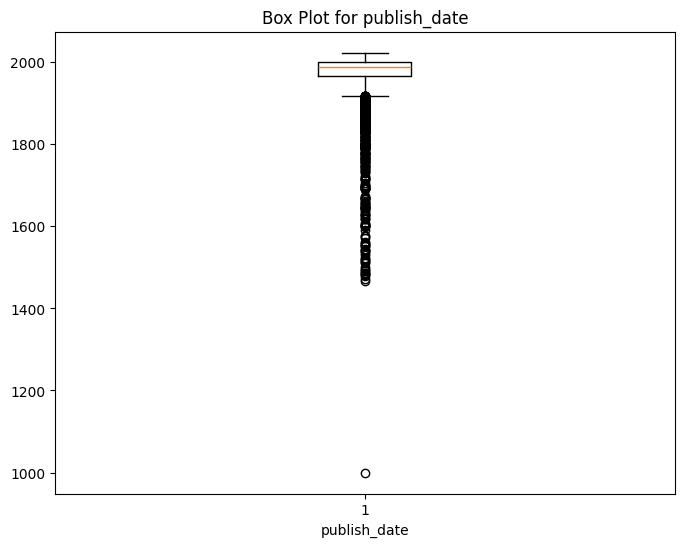

In [17]:
# Convert the publish_date column to numeric values (if it contains non-numeric values)
df['publish_date'] = pd.to_numeric(df['publish_date'], errors='coerce')

plt.figure(figsize=(8, 6))
plt.boxplot(df['publish_date'].dropna())  
plt.title('Box Plot for publish_date')
plt.xlabel('publish_date')
plt.show()


In [18]:
# calculate IQR
Q1 = df['publish_date'].quantile(0.25)  
Q3 = df['publish_date'].quantile(0.75)  
IQR = Q3 - Q1  

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# removing outliers
df = df[(df['publish_date'] >= lower_bound) & (df['publish_date'] <= upper_bound)]

# Reset the index to be sequential
df.reset_index(drop=True, inplace=True)



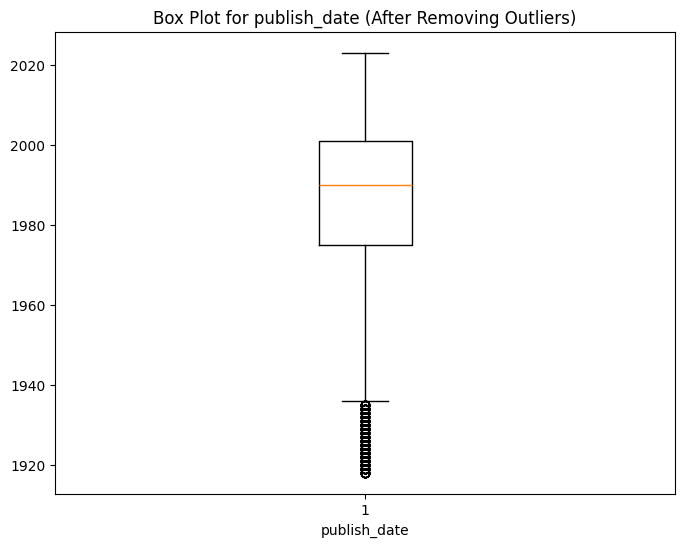

In [19]:

plt.figure(figsize=(8, 6))
plt.boxplot(df['publish_date'].dropna())  
plt.title('Box Plot for publish_date (After Removing Outliers)')
plt.xlabel('publish_date')
plt.show()

In [20]:
df.describe()

,publish_date,num_pages,edition_count,covers_count,average_rating,rating_count
count,7846.000000,7846.000000,7846.000000,7846.000000,7846.000000,7846.000000
mean,1986.035050,327.329977,9.547158,2.085776,1.521811,3.468137
std,20.315671,225.059802,18.515217,2.780641,1.979863,26.034569
min,1918.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1975.000000,190.000000,4.000000,1.000000,0.000000,0.000000
50%,1990.000000,286.000000,6.000000,1.000000,0.000000,0.000000
75%,2001.000000,411.000000,10.000000,2.000000,3.800000,1.000000
max,2023.000000,4002.000000,678.000000,50.000000,5.000000,938.000000


In [21]:
df.shape

(7846, 11)

# Regular Expressions (Regex) 

### Extract and clean the subjects column

In [22]:
import re

def clean_subjects(subjects):
    if isinstance(subjects, str):  # Check if the value is text
        # Remove special characters and keep only letters, numbers, spaces, and commas
        cleaned = re.sub(r'[^\w\s,]', '', subjects)
        # Split text into a list based on commas
        return [subject.strip() for subject in cleaned.split(',')]
    return []

df['cleaned_subjects'] = df['subjects'].apply(clean_subjects)

df[['subjects', 'cleaned_subjects']].head()

,subjects,cleaned_subjects
0,"American Science fiction, Ciencia-ficción, Dra...","[American Science fiction, Cienciaficción, Dra..."
1,"Miscellanea, Meteorology, Astronomy, Curiositi...","[Miscellanea, Meteorology, Astronomy, Curiosit..."
2,"Human-computer interaction, Computers, Fiction...","[Humancomputer interaction, Computers, Fiction..."
3,"Dune (Imaginary place), Fiction, Fiction, scie...","[Dune Imaginary place, Fiction, Fiction, scien..."
4,"Cosmologie, Temps (durée), Espace-temps, Vulga...","[Cosmologie, Temps durée, Espacetemps, Vulgari..."


### Extract and clean the url column

In [23]:
def extract_urls(text):
    if isinstance(text, str): 
        return re.findall(r'https?://[^\s]+', text)
    return []

df['extracted_urls'] = df['url'].apply(extract_urls)

df[['url', 'extracted_urls']].head()

,url,extracted_urls
0,https://openlibrary.org/works/OL103134W,[https://openlibrary.org/works/OL103134W]
1,https://openlibrary.org/works/OL66059W,[https://openlibrary.org/works/OL66059W]
2,https://openlibrary.org/works/OL17365W,[https://openlibrary.org/works/OL17365W]
3,https://openlibrary.org/works/OL893415W,[https://openlibrary.org/works/OL893415W]
4,https://openlibrary.org/works/OL1892617W,[https://openlibrary.org/works/OL1892617W]


### Extract the genres from the texts in the `subjects` column.

In [24]:
def extract_genres(subjects):
    if isinstance(subjects, str):
        return re.findall(r'\b(Science fiction|Fantasy|Horror|Drama|Comedy)\b', subjects)
    return []

df['genres'] = df['subjects'].apply(extract_genres)
df[['subjects', 'genres']].head()

,subjects,genres
0,"American Science fiction, Ciencia-ficción, Dra...","[Science fiction, Drama, Science fiction]"
1,"Miscellanea, Meteorology, Astronomy, Curiositi...",[]
2,"Human-computer interaction, Computers, Fiction...","[Science fiction, Science fiction]"
3,"Dune (Imaginary place), Fiction, Fiction, scie...","[Science fiction, Science fiction, Fantasy]"
4,"Cosmologie, Temps (durée), Espace-temps, Vulga...",[]


### Extract the languages from the texts in the `subjects` column.

In [25]:
def extract_languages(subjects):
    if isinstance(subjects, str):
        return re.findall(r'\b(English|French|Spanish|German|Arabic|Eng|Fr|Sp|Français)\b', subjects)
    return []

df['languages'] = df['subjects'].apply(extract_languages)
df[['subjects', 'languages']].head()


,subjects,languages
0,"American Science fiction, Ciencia-ficción, Dra...",[English]
1,"Miscellanea, Meteorology, Astronomy, Curiositi...",[]
2,"Human-computer interaction, Computers, Fiction...","[English, English]"
3,"Dune (Imaginary place), Fiction, Fiction, scie...",[]
4,"Cosmologie, Temps (durée), Espace-temps, Vulga...",[]


### Extract the numbers from the texts in the `subjects` column.

In [26]:
def extract_numbers(subjects):
    if isinstance(subjects, str):
        return re.findall(r'\d+\.?\d*', subjects)
    return []

df['numbers'] = df['subjects'].apply(extract_numbers)
df[['subjects', 'numbers']].head()

,subjects,numbers
0,"American Science fiction, Ciencia-ficción, Dra...",[]
1,"Miscellanea, Meteorology, Astronomy, Curiositi...",[]
2,"Human-computer interaction, Computers, Fiction...",[]
3,"Dune (Imaginary place), Fiction, Fiction, scie...","[2021, 11, 07, 2021, 11, 07, 1966]"
4,"Cosmologie, Temps (durée), Espace-temps, Vulga...","[2018, 04, 08, 2014, 03, 09]"


# ========Data Analysis=========

### ***Show the first 5 rows before starting the analysis***

In [27]:
df.head()

,title,author,publish_date,language,num_pages,edition_count,subjects,covers_count,average_rating,rating_count,url,cleaned_subjects,extracted_urls,genres,languages,numbers
0,The Martian Chronicles,Ray Bradbury,1950,eng,272.0,137,"American Science fiction, Ciencia-ficción, Dra...",2.0,4.089109,101,https://openlibrary.org/works/OL103134W,"[American Science fiction, Cienciaficción, Dra...",[https://openlibrary.org/works/OL103134W],"[Science fiction, Drama, Science fiction]",[English],[]
1,The book of the damned,Charles Fort,1919,por,226.0,120,"Miscellanea, Meteorology, Astronomy, Curiositi...",3.0,4.000000,2,https://openlibrary.org/works/OL66059W,"[Miscellanea, Meteorology, Astronomy, Curiosit...",[https://openlibrary.org/works/OL66059W],[],[],[]
2,2001,Arthur C. Clarke,1968,eng,217.0,116,"Human-computer interaction, Computers, Fiction...",23.0,4.191667,120,https://openlibrary.org/works/OL17365W,"[Humancomputer interaction, Computers, Fiction...",[https://openlibrary.org/works/OL17365W],"[Science fiction, Science fiction]","[English, English]",[]
3,Dune,Frank Herbert,1965,eng,592.0,115,"Dune (Imaginary place), Fiction, Fiction, scie...",32.0,4.279133,369,https://openlibrary.org/works/OL893415W,"[Dune Imaginary place, Fiction, Fiction, scien...",[https://openlibrary.org/works/OL893415W],"[Science fiction, Science fiction, Fantasy]",[],"[2021, 11, 07, 2021, 11, 07, 1966]"
4,A Brief History of Time,Stephen Hawking,1988,eng,1.0,119,"Cosmologie, Temps (durée), Espace-temps, Vulga...",50.0,4.157635,203,https://openlibrary.org/works/OL1892617W,"[Cosmologie, Temps durée, Espacetemps, Vulgari...",[https://openlibrary.org/works/OL1892617W],[],[],"[2018, 04, 08, 2014, 03, 09]"


### Display data information

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7846 entries, 0 to 7845
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             7846 non-null   object 
 1   author            7846 non-null   object 
 2   publish_date      7846 non-null   int32  
 3   language          7846 non-null   object 
 4   num_pages         7846 non-null   float64
 5   edition_count     7846 non-null   int64  
 6   subjects          7846 non-null   object 
 7   covers_count      7846 non-null   float64
 8   average_rating    7846 non-null   float64
 9   rating_count      7846 non-null   int32  
 10  url               7846 non-null   object 
 11  cleaned_subjects  7846 non-null   object 
 12  extracted_urls    7846 non-null   object 
 13  genres            7846 non-null   object 
 14  languages         7846 non-null   object 
 15  numbers           7846 non-null   object 
dtypes: float64(3), int32(2), int64(1), object(

### Print statistics about the book data

In [29]:
# Number of books
print("Number of books:", len(df))

# Page count stats
print("\n Number of Pages:")
print(" - Mean:", df['num_pages'].mean())
print(" - Min:", df['num_pages'].min())
print(" - Max:", df['num_pages'].max())

# Rating stats
print("\n Average Ratings:")
print(" - Mean:", df['average_rating'].mean())
print(" - Min:", df['average_rating'].min())
print(" - Max:", df['average_rating'].max())

# Rating count stats
print("\n Rating Count:")
print(" - Mean:", df['rating_count'].mean())
print(" - Max:", df['rating_count'].max())

# Edition count stats
print("\n Edition Count:")
print(" - Mean:", df['edition_count'].mean())
print(" - Max:", df['edition_count'].max())


Number of books: 7846

 Number of Pages:
 - Mean: 327.3299770583737
 - Min: 0.0
 - Max: 4002.0

 Average Ratings:
 - Mean: 1.521810623866312
 - Min: 0.0
 - Max: 5.0

 Rating Count:
 - Mean: 3.4681366301300027
 - Max: 938

 Edition Count:
 - Mean: 9.547157787407595
 - Max: 678


### descriptive statistics for the DataFrame

In [30]:
df.describe()

,publish_date,num_pages,edition_count,covers_count,average_rating,rating_count
count,7846.000000,7846.000000,7846.000000,7846.000000,7846.000000,7846.000000
mean,1986.035050,327.329977,9.547158,2.085776,1.521811,3.468137
std,20.315671,225.059802,18.515217,2.780641,1.979863,26.034569
min,1918.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1975.000000,190.000000,4.000000,1.000000,0.000000,0.000000
50%,1990.000000,286.000000,6.000000,1.000000,0.000000,0.000000
75%,2001.000000,411.000000,10.000000,2.000000,3.800000,1.000000
max,2023.000000,4002.000000,678.000000,50.000000,5.000000,938.000000


### prints the most common language in the 'language' column of the DataFrame

In [31]:
print("Most common language:", df['language'].mode()[0]) #mode() function returns the most frequent value in a column

Most common language: eng


In [32]:
#calculates the count and percentage of each language in the 'language' column.
language_counts = df['language'].value_counts()
language_dist = df['language'].value_counts(normalize=True) * 100

# Combine counts and percentages into a single DataFrame
language_summary = pd.DataFrame({
    'Count': language_counts,
    'Percentage': language_dist.apply(lambda x: f"{x:.2f}%")
})
# Print the top 3 most common languages and the 3 least used languages
print("The 3 most famous languages:")
print(language_summary.head(3))
print("\n===============================================")
print("\nThe 3 least used languages:")
print(language_summary.tail(3))


The 3 most famous languages:
          Count Percentage
language                  
eng        6695     85.33%
fre         286      3.65%
spa         253      3.22%


The 3 least used languages:
          Count Percentage
language                  
vie           1      0.01%
hat           1      0.01%
ukr           1      0.01%


In [33]:
# Sort the DataFrame by 'num_pages' in descending order
books_by_pages = df.sort_values(by='num_pages', ascending=False).reset_index(drop=True)

# Display the book(s) with the highest number of pages
print("\nBook with the highest number of pages:")
print(books_by_pages[['title', 'author', 'num_pages', 'url']].head(3))  # Display the 3 top book


Book with the highest number of pages:
                           title             author  num_pages  \
0  Study guide for earth science  Kenneth G. Pinzke     4002.0   
1    The sciences and philosophy      J. S. Haldane     3330.0   
2            Machinerys Handbook         Erik Oberg     2896.0   

                                        url  
0    https://openlibrary.org/works/OL29604W  
1  https://openlibrary.org/works/OL7137643W  
2  https://openlibrary.org/works/OL7707183W  


In [34]:
# Sort the DataFrame by 'edition_count' in descending order
books_by_edition = df.sort_values(by='edition_count', ascending=False).reset_index(drop=True)

# Display the book(s) with the highest number of pages
print("\nBook with the highest number of edition_count:")
print(books_by_edition[['title', 'author', 'edition_count', 'url']].head(3))  # Display the 3 top book


Book with the highest number of edition_count:
                  title          author  edition_count  \
0       Brave New World   Aldous Huxley            678   
1            The Hobbit  J.R.R. Tolkien            457   
2  Nineteen Eighty-Four   George Orwell            433   

                                        url  
0    https://openlibrary.org/works/OL64365W  
1    https://openlibrary.org/works/OL27482W  
2  https://openlibrary.org/works/OL1168083W  


### calculates the average rating for each language in the 'language' column.

In [35]:
#it uses 'groupby()' to group the data by language and then calculates the mean of the 'average_rating' for each group.
lang_rating = df.groupby('language')['average_rating'].mean().sort_values(ascending=False)

# Print the top 10 languages with the highest average ratings
print(" Average Rating by Language:")
print(lang_rating.head(10))



 Average Rating by Language:
language
gle    5.000000
gre    5.000000
bul    4.299757
tha    4.296709
hat    4.157895
fin    3.852564
ang    3.666667
vie    3.666667
rum    3.172741
wel    3.111111
Name: average_rating, dtype: float64


In [36]:
# Most frequent authors
print("Top 10 Authors by Count:")
print(df['author'].value_counts().head(10))


Top 10 Authors by Count:
author
Isaac Asimov           182
Andre Norton            86
Robert Silverberg       60
Piers Anthony           52
Alan Dean Foster        48
C. J. Cherryh           43
Arthur C. Clarke        39
Katherine Applegate     39
David Weber             37
James Blish             36
Name: count, dtype: int64


In [37]:
#prints the top 10 most common publishing years
print("Top 10 Publishing Years by Number of Books:")
print(df['publish_date'].value_counts().sort_values(ascending=False).head(10)) #sort_index(ascending=False)' sorts the years in descending order


Top 10 Publishing Years by Number of Books:
publish_date
1997    205
1995    197
1998    193
1999    189
1996    187
1994    178
2000    176
2001    166
1991    161
2007    159
Name: count, dtype: int64


In [38]:
#prints the oldest publishing years 
print("Oldest Publish Years:")
print(df['publish_date'].value_counts().sort_values().head(10))


Oldest Publish Years:
publish_date
2023     1
2019     3
2021     3
1932     7
1927     8
1928     8
1933     8
1931     9
1942    10
1941    10
Name: count, dtype: int64


### identifies the top 10 most common subjects across all books in the 'subjects' column.

In [39]:
subjects_series = df['subjects'].dropna().str.split(', ')  # Remove NaN and split subjects
flat_subjects = pd.Series([item for sublist in subjects_series for item in sublist])  # Flatten the list
top_subjects = flat_subjects.value_counts().head(10)  # Get the top 10 most common subjects
print("Top 10 Subjects:")
print(top_subjects)


Top 10 Subjects:
Fiction                     6186
general                     2798
science fiction             2596
fiction                     2382
Science fiction             1837
Science                     1474
American Science fiction     816
Children's fiction           760
History                      737
Juvenile fiction             521
Name: count, dtype: int64


### identifies the top 10 most common literary genres from the 'genres' column.

In [40]:
df_exploded = df.explode('genres')  # Explode the 'genres' column into separate rows
top_genres = df_exploded['genres'].value_counts().head(10)  # Count the most frequent genres
print("The 10 Most Common Literary Genres: ")
print(top_genres)

The 10 Most Common Literary Genres: 
genres
Science fiction    3088
Fantasy             994
Horror              212
Drama                28
Comedy                2
Name: count, dtype: int64


### calculates the correlation between 'rating_count' and 'average_rating'.

In [41]:
# Calculate the correlation
cor = df[['rating_count','average_rating']].corr().iloc[0, 1]
#prints the correlation with two decimal places.
print(f" Correlation between Rating Count and Average Rating: {cor:.2f}")


 Correlation between Rating Count and Average Rating: 0.17


### computes the correlation matrix for a set of numeric columns in the DataFrame.

In [42]:
# Define numeric columns
numeric_cols = ['num_pages', 'edition_count', 'average_rating', 'rating_count', 'covers_count']  
# Calculate the correlation matrix for these columns
correlation_matrix = df[numeric_cols].corr()  
print("The Correlation Matrix :")
print(correlation_matrix)


The Correlation Matrix :
                num_pages  edition_count  average_rating  rating_count  \
num_pages        1.000000       0.013641        0.013001      0.019789   
edition_count    0.013641       1.000000        0.173683      0.637834   
average_rating   0.013001       0.173683        1.000000      0.168833   
rating_count     0.019789       0.637834        0.168833      1.000000   
covers_count     0.006907       0.555775        0.239801      0.437969   

                covers_count  
num_pages           0.006907  
edition_count       0.555775  
average_rating      0.239801  
rating_count        0.437969  
covers_count        1.000000  


###  generates a heatmap to visualize the correlation matrix for the numeric columns

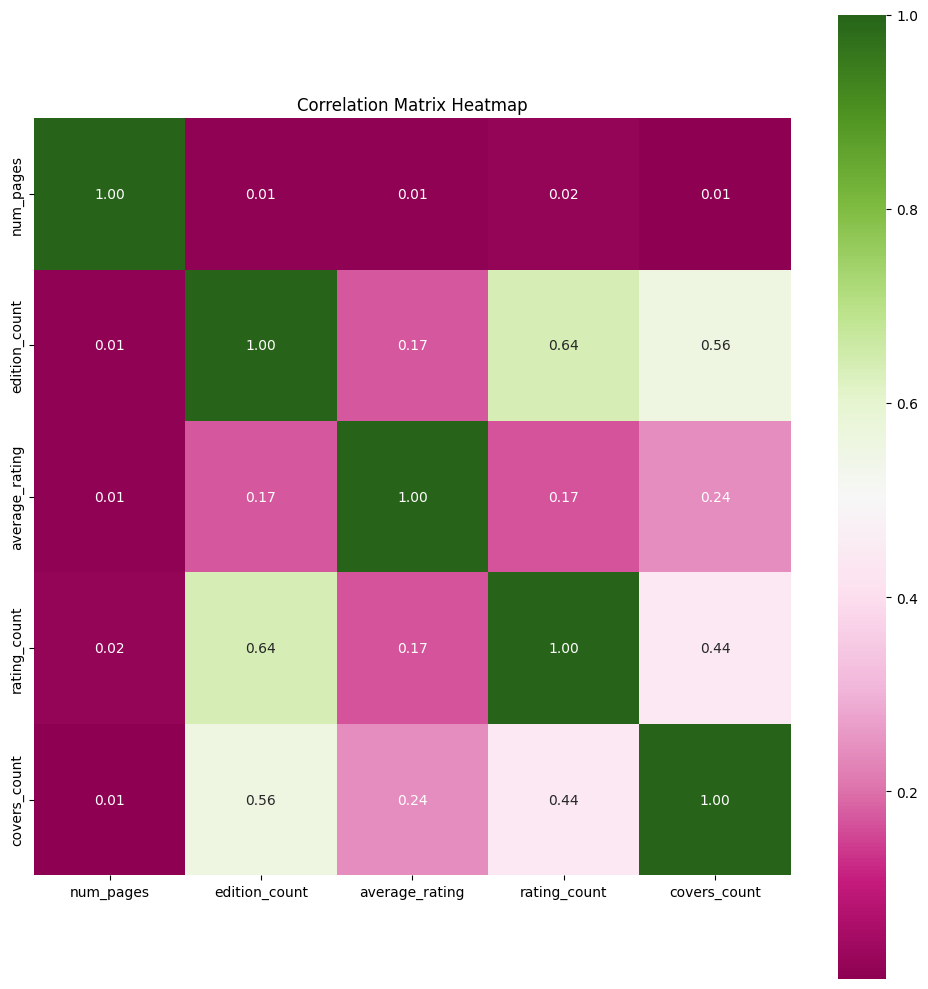

In [43]:
plt.figure(figsize=(10, 10))
# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="PiYG", square=True)
 # Add title
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

### filters and displays pairs of columns with a correlation greater than 0.5.

In [44]:
threshold = 0.5  # Set the correlation threshold
high_corr = correlation_matrix[(correlation_matrix > threshold) & (correlation_matrix != 1)]  # Filter by threshold and remove self-correlation

high_corr = high_corr.stack().reset_index(name="Correlation")  # Reshape and reset index
high_corr.columns = ['Column 1', 'Column 2', 'Correlation']  # Rename columns
print("\n High Correlations (Greater than 0.5):")
print(high_corr)



 High Correlations (Greater than 0.5):
        Column 1       Column 2  Correlation
0  edition_count   rating_count     0.637834
1  edition_count   covers_count     0.555775
2   rating_count  edition_count     0.637834
3   covers_count  edition_count     0.555775


### sorts the books by 'average_rating' in descending order and displays the top 10 books.

In [45]:
sorted_by_average_rating= df.sort_values(by='average_rating', ascending=False).reset_index()

print("\n Books sorted by rating count (Highest to Lowest):")
print(sorted_by_average_rating[['title','author','average_rating','url']].head(10))


 Books sorted by rating count (Highest to Lowest):
                                       title               author  \
0      Statistical methods in bioinformatics          W. J. Ewens   
1                     Where Did I Come From?          Peter Mayle   
2                   The structure of science         Ernest Nagel   
3  Foundations of Python network programming         John Goerzen   
4                 Shake hands with the devil       Roméo Dallaire   
5                               Talking nets   Anderson, James A.   
6                                  Geography        Ian Whittaker   
7                         Brave the Betrayal  Katherine Applegate   
8                        Design and Analysis      Geoffrey Keppel   
9                            Dinosaur Planet       Anne McCaffrey   

   average_rating                                        url  
0             5.0  https://openlibrary.org/works/OL12337366W  
1             5.0     https://openlibrary.org/works/OL80511W  

In [46]:
# Filter books with a rating of 5
books_with_5_rating = df[df['average_rating'] == 5]

# Get the number of books with a rating of 5
num_books_with_5_rating = books_with_5_rating.shape[0]

# Print the result
print(f"Number of books with a rating of 5: {num_books_with_5_rating}")


Number of books with a rating of 5: 653


### sorts the books by 'rating_count' in descending order and displays the top 10 books.

In [47]:
sorted_by_rating_count = df.sort_values(by='rating_count', ascending=False).reset_index()

print("\n Books sorted by rating count (Highest to Lowest):")
print(sorted_by_rating_count[['title','author','rating_count','average_rating','url']].head(10))



 Books sorted by rating count (Highest to Lowest):
                                      title               author  \
0                      The 48 Laws of Power        Robert Greene   
1  Harry Potter and the Philosopher's Stone        J. K. Rowling   
2                         A Game of Thrones  George R. R. Martin   
3  Harry Potter and the Prisoner of Azkaban        J. K. Rowling   
4                               Animal Farm        George Orwell   
5                                The Hobbit       J.R.R. Tolkien   
6                          The Hunger Games      Suzanne Collins   
7                           Brave New World        Aldous Huxley   
8                            Fahrenheit 451         Ray Bradbury   
9                              Ender's Game     Orson Scott Card   

   rating_count  average_rating                                       url  
0           938        4.078891  https://openlibrary.org/works/OL1968368W  
1           824        4.235437    https://open

### applies K-Means clustering

In [48]:
from sklearn.cluster import KMeans  # Import KMeans for clustering
from sklearn.decomposition import PCA  # Import PCA for dimensionality reduction

# Select relevant features for clustering
X = df[['average_rating', 'rating_count']]  # Features for clustering

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)  # Reduce to 2 components
X_pca = pca.fit_transform(X)  # Apply PCA

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3)  # Set the number of clusters to 3
df['Cluster'] = kmeans.fit_predict(X_pca)  # Predict clusters and assign to new column

# Display the result
print(df[['title', 'Cluster']].head())  # Print the title and assigned cluster for the first few rows


                     title  Cluster
0   The Martian Chronicles        2
1   The book of the damned        0
2                     2001        2
3                     Dune        1
4  A Brief History of Time        2


### applies the Apriori algorithm to find frequent itemsets and association rules in the 'subjects' column.

In [49]:
from mlxtend.frequent_patterns import apriori, association_rules  # Import necessary functions

# One-hot encode the 'subjects' column
df_one_hot = df['subjects'].str.get_dummies(sep=', ')  # Convert subjects to one-hot encoded format

# Convert the DataFrame to boolean to avoid the warning and improve performance
df_one_hot = df_one_hot.astype(bool)

# Find frequent itemsets with a minimum support of 0.05
frequent_itemsets = apriori(df_one_hot, min_support=0.05, use_colnames=True)  # Apply Apriori algorithm

# Generate association rules with "lift" metric and minimum threshold of 1.0
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)  # Generate rules

# Display the results
print(rules)  # Print the generated association rules

                    antecedents                          consequents  \
0                     (Fiction)           (American Science fiction)   
1    (American Science fiction)                            (Fiction)   
2    (American Science fiction)                            (general)   
3                     (general)           (American Science fiction)   
4             (science fiction)           (American Science fiction)   
..                          ...                                  ...   
161          (general, fiction)           (science fiction, Fiction)   
162           (science fiction)          (Fiction, general, fiction)   
163                   (Fiction)  (science fiction, general, fiction)   
164                   (general)  (science fiction, Fiction, fiction)   
165                   (fiction)  (science fiction, Fiction, general)   

     antecedent support  consequent support   support  confidence      lift  \
0              0.422126            0.104002  0.078384   

# ======= Data Visualization ========

### Boxplots to show the distribution of the Numeric columns in the dataset

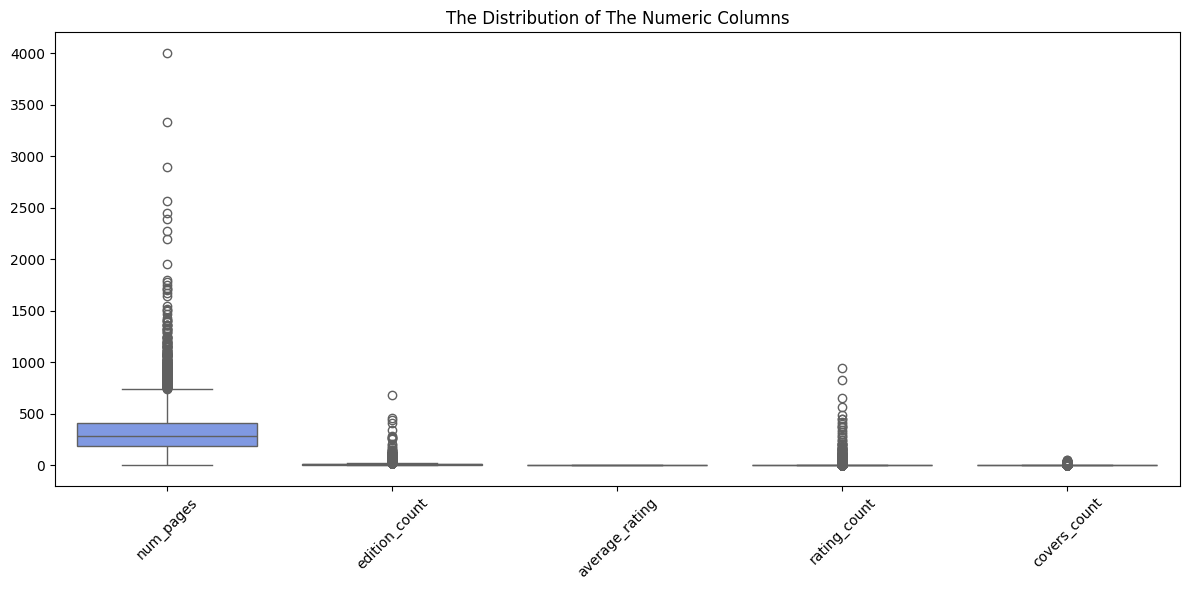

In [50]:
# Set the size of the figure
plt.figure(figsize=(12, 6))
# Create a boxplot for all numeric columns to show their distribution
sns.boxplot(data=df[numeric_cols], palette='coolwarm')
# Set the title of the plot
plt.title("The Distribution of The Numeric Columns")
# Rotate the x-axis labels by 45 degrees for better readability
plt.xticks(rotation=45)
# Adjust the layout to prevent overlapping elements
plt.tight_layout()
# Display the plot
plt.show()

### Subplot to collect 4 different plots for Books Analysis As the plots shows the Relationship of the Books title and each
### of the Average rating and the edition counts and the covers counts and the number of pages for each book

C:\Users\KING\AppData\Local\Temp\ipykernel_20420\1147754090.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='title', x='edition_count', data=book_edition, palette=color22, ax=axs[0, 1])
C:\Users\KING\AppData\Local\Temp\ipykernel_20420\1147754090.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='title', x='covers_count', data=book_cover, palette=color33, ax=axs[1, 0])
C:\Users\KING\AppData\Local\Temp\ipykernel_20420\1147754090.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='title', x='num_pages', data=book_page, palette=c

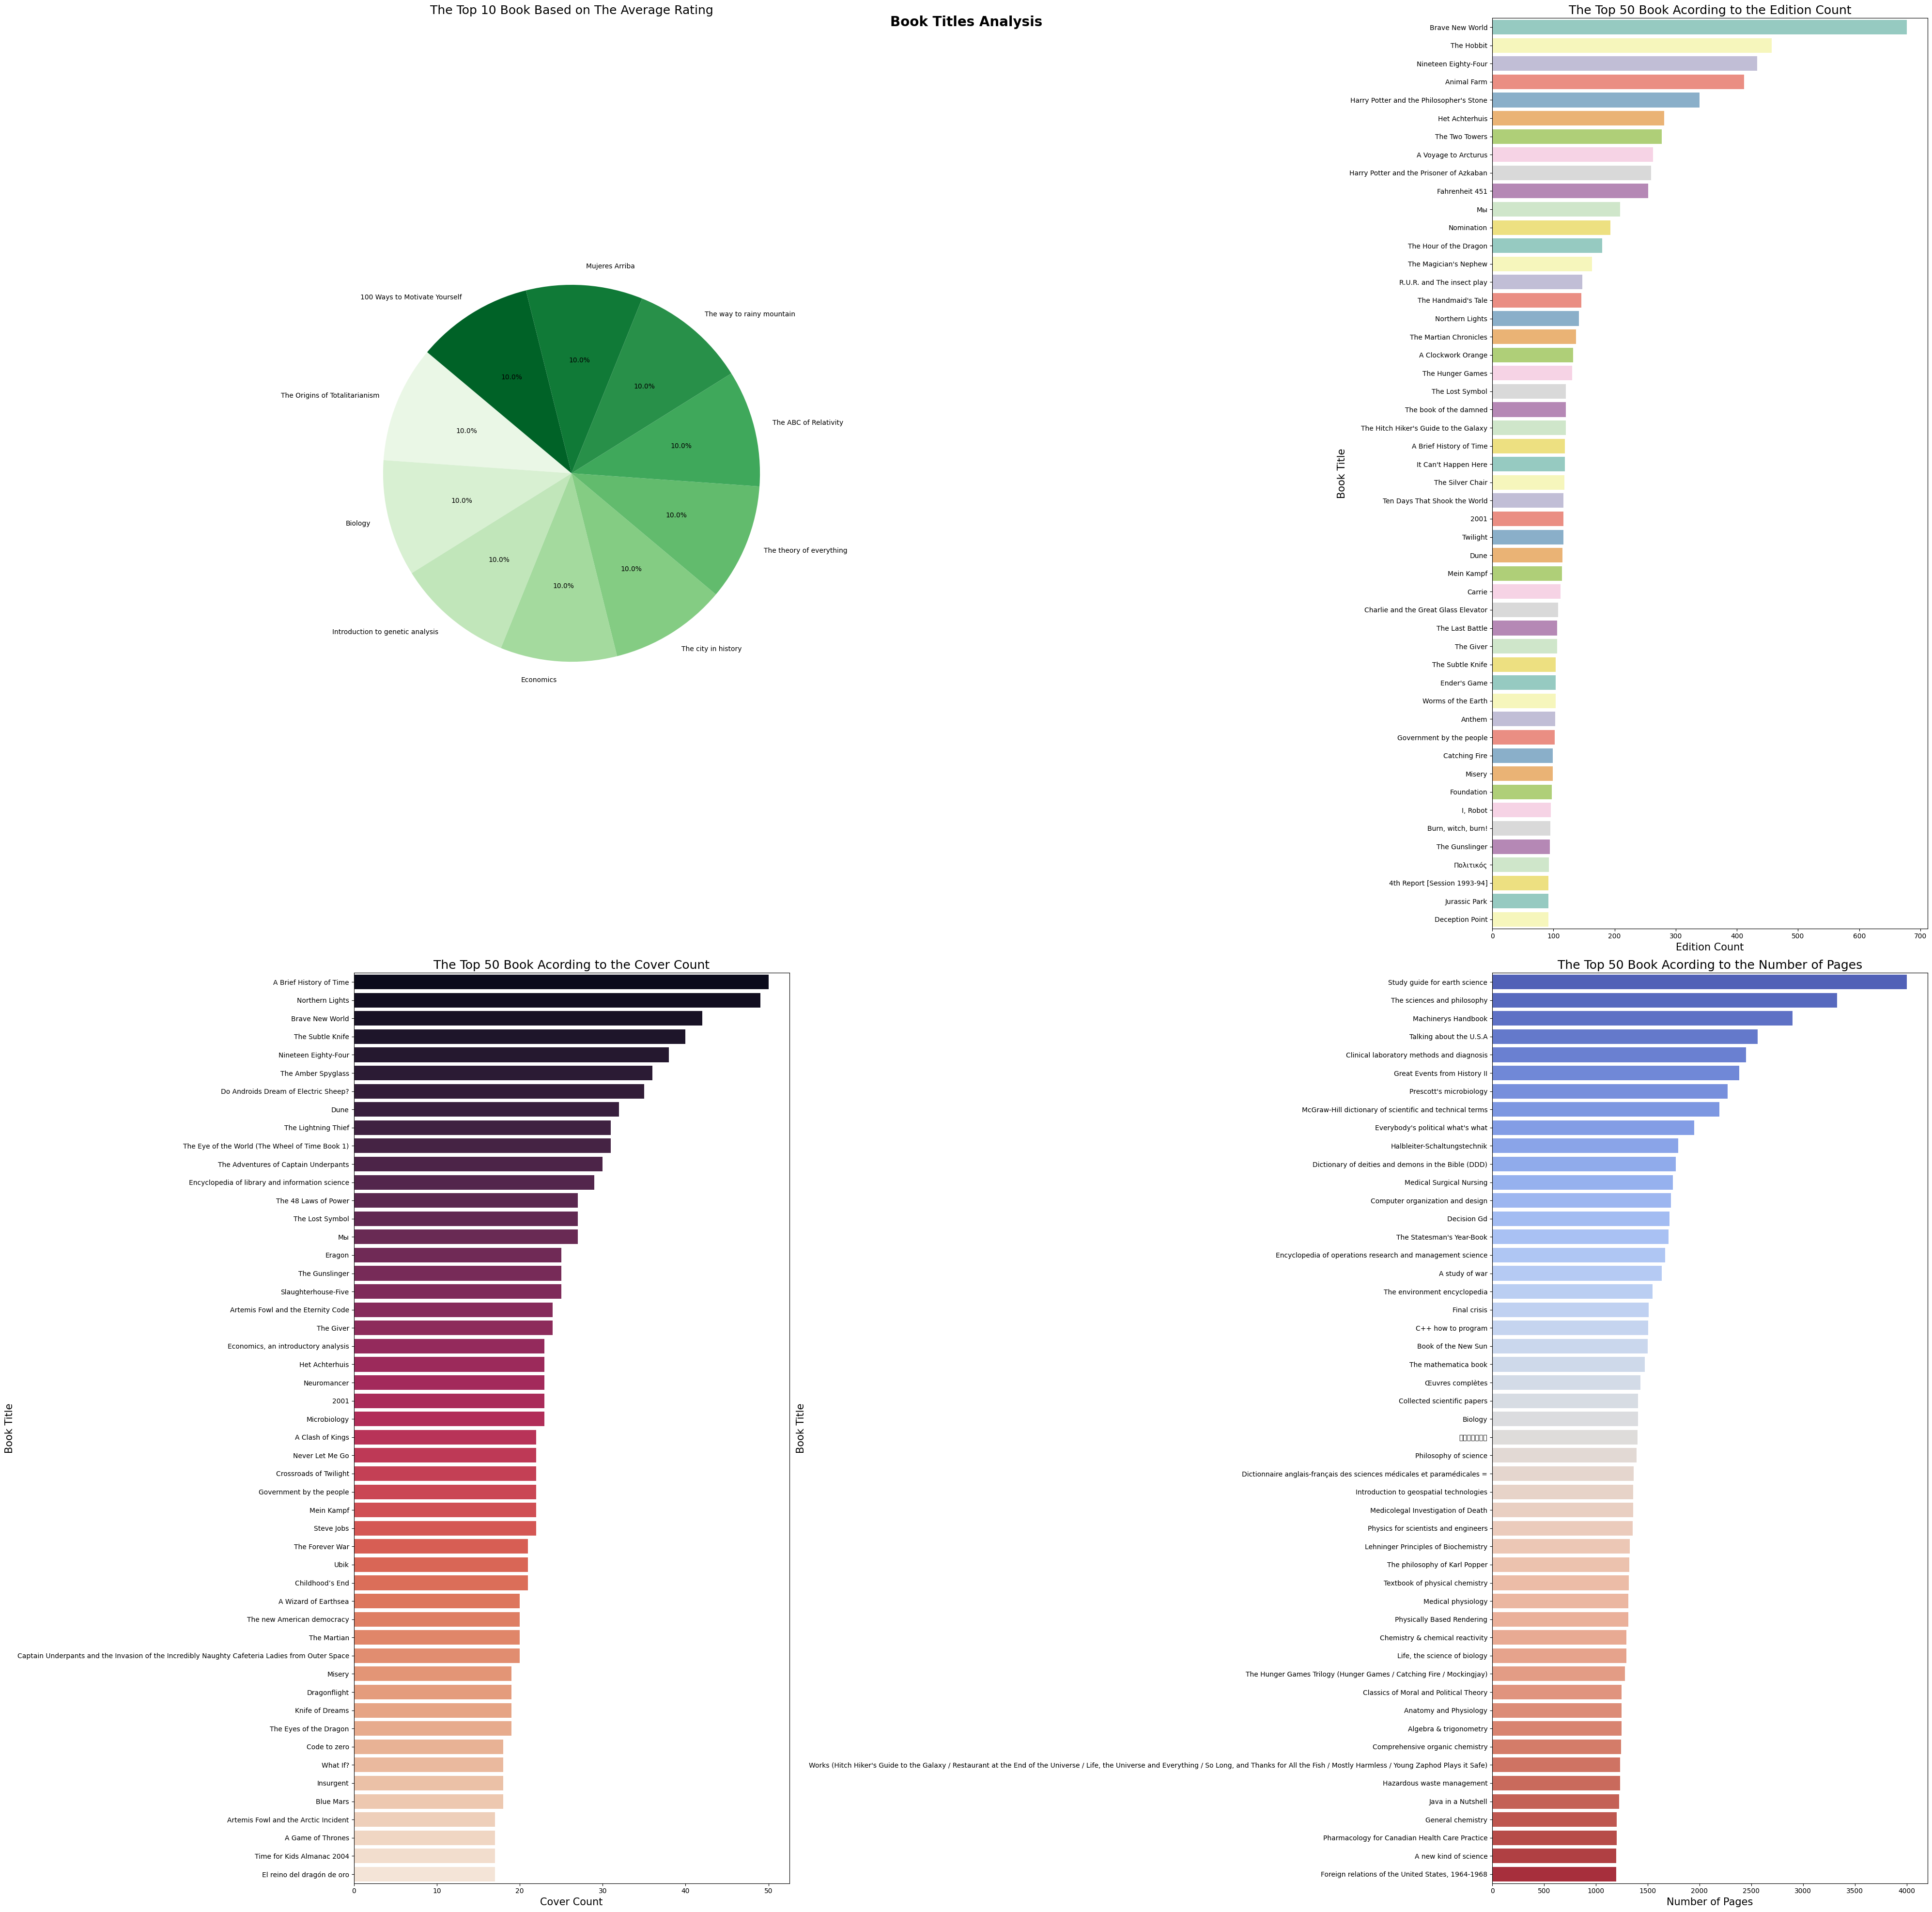

In [51]:
# Set the default font for all plots to 'DejaVu Sans' because there languages like chinese
plt.rcParams['font.family'] = 'DejaVu Sans'
# Set the number of top rated books that will be displayed
num =10
# Get the top 10 book ratings
book_rating =df.nlargest(num, 'average_rating')
# Set the colors for the book_rating plot As for each book a different color
color11 =sns.color_palette("Greens", len(book_rating))

# Get the top 50 books with the highest edition counts
book_edition = df.sort_values('edition_count', ascending=False).head(50)
# Set the colors for the book_edition plot As for each book a different color
color22 =sns.color_palette("Set3", 50)

# Get the top 50 books with the highest number of covers
book_cover = df.sort_values('covers_count', ascending=False).head(50)
# Set the colors for the book_cover plot As for each book a different color
color33 =sns.color_palette("rocket", 50)

# Get the top 50 books with the most number of pages
book_page = df.sort_values('num_pages', ascending=False).head(50)
# Set the colors for the book_page plot As for each book a different color
color44 =sns.color_palette("coolwarm", 50)

# Create a 2x2 subplots with a large figure size
fig, axs =plt.subplots(2, 2, figsize=(40, 40))
# Set the main title for the whole figure
fig.suptitle('Book Titles Analysis', fontsize=20, fontweight='bold')
# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Subplot 1: Pie chart of average ratings for the Books
axs[0, 0].pie(book_rating['average_rating'], labels=book_rating['title'], autopct='%1.1f%%', colors=color11, startangle=140)
axs[0, 0].axis('equal')  # Ensure the pie chart is circular
axs[0, 0].set_title("The Top 10 Book Based on The Average Rating", fontsize=18)


# Subplot 2: Bar chart (Horizontal barplot) of edition counts for each Book
sns.barplot(y='title', x='edition_count', data=book_edition, palette=color22, ax=axs[0, 1])
axs[0, 1].set_title("The Top 50 Book Acording to the Edition Count", fontsize=18)
axs[0, 1].set_xlabel("Edition Count", fontsize=15)
axs[0, 1].set_ylabel("Book Title", fontsize=15)
axs[0, 1].tick_params(axis='y', labelsize=10)

# Subplot 3: Bar chart ((Horizontal barplot)) of cover counts for each Book
sns.barplot(y='title', x='covers_count', data=book_cover, palette=color33, ax=axs[1, 0])
axs[1, 0].set_title("The Top 50 Book Acording to the Cover Count", fontsize=18)
axs[1, 0].set_xlabel("Cover Count", fontsize=15)
axs[1, 0].set_ylabel("Book Title", fontsize=15)
axs[1, 0].tick_params(axis='y', labelsize=10)

# Subplot 4: Bar chart ((Horizontal barplot)) of number of pages for each Book
sns.barplot(y='title', x='num_pages', data=book_page, palette=color44, ax=axs[1, 1])
axs[1, 1].set_title("The Top 50 Book Acording to the Number of Pages", fontsize=18)
axs[1, 1].set_xlabel("Number of Pages", fontsize=15)
axs[1, 1].set_ylabel("Book Title", fontsize=15)
axs[1, 1].tick_params(axis='y', labelsize=10)

# Automatically adjust layout to avoid overlap
plt.tight_layout()
# Display the final figure with all subplots
plt.show()

### Subplot to collect 4 different plots for Language Analysis As the plots shows the Relationship of the each language
### and each of the Average rating and the edition counts and the covers counts and also plot to show the count of each Language

C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2937541099.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_edition.index, y=lang_edition.values, ax=axs[1, 0], palette=colors)
C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2937541099.py:25: UserWarning: 
The palette list has fewer values (8) than needed (37) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=lang_edition.index, y=lang_edition.values, ax=axs[1, 0], palette=colors)
C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2937541099.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_cover.index, y=lang_cover.values, ax=axs[1, 1], palette=colors)
C:\Users\KING\AppData\Local\Temp\ipykernel

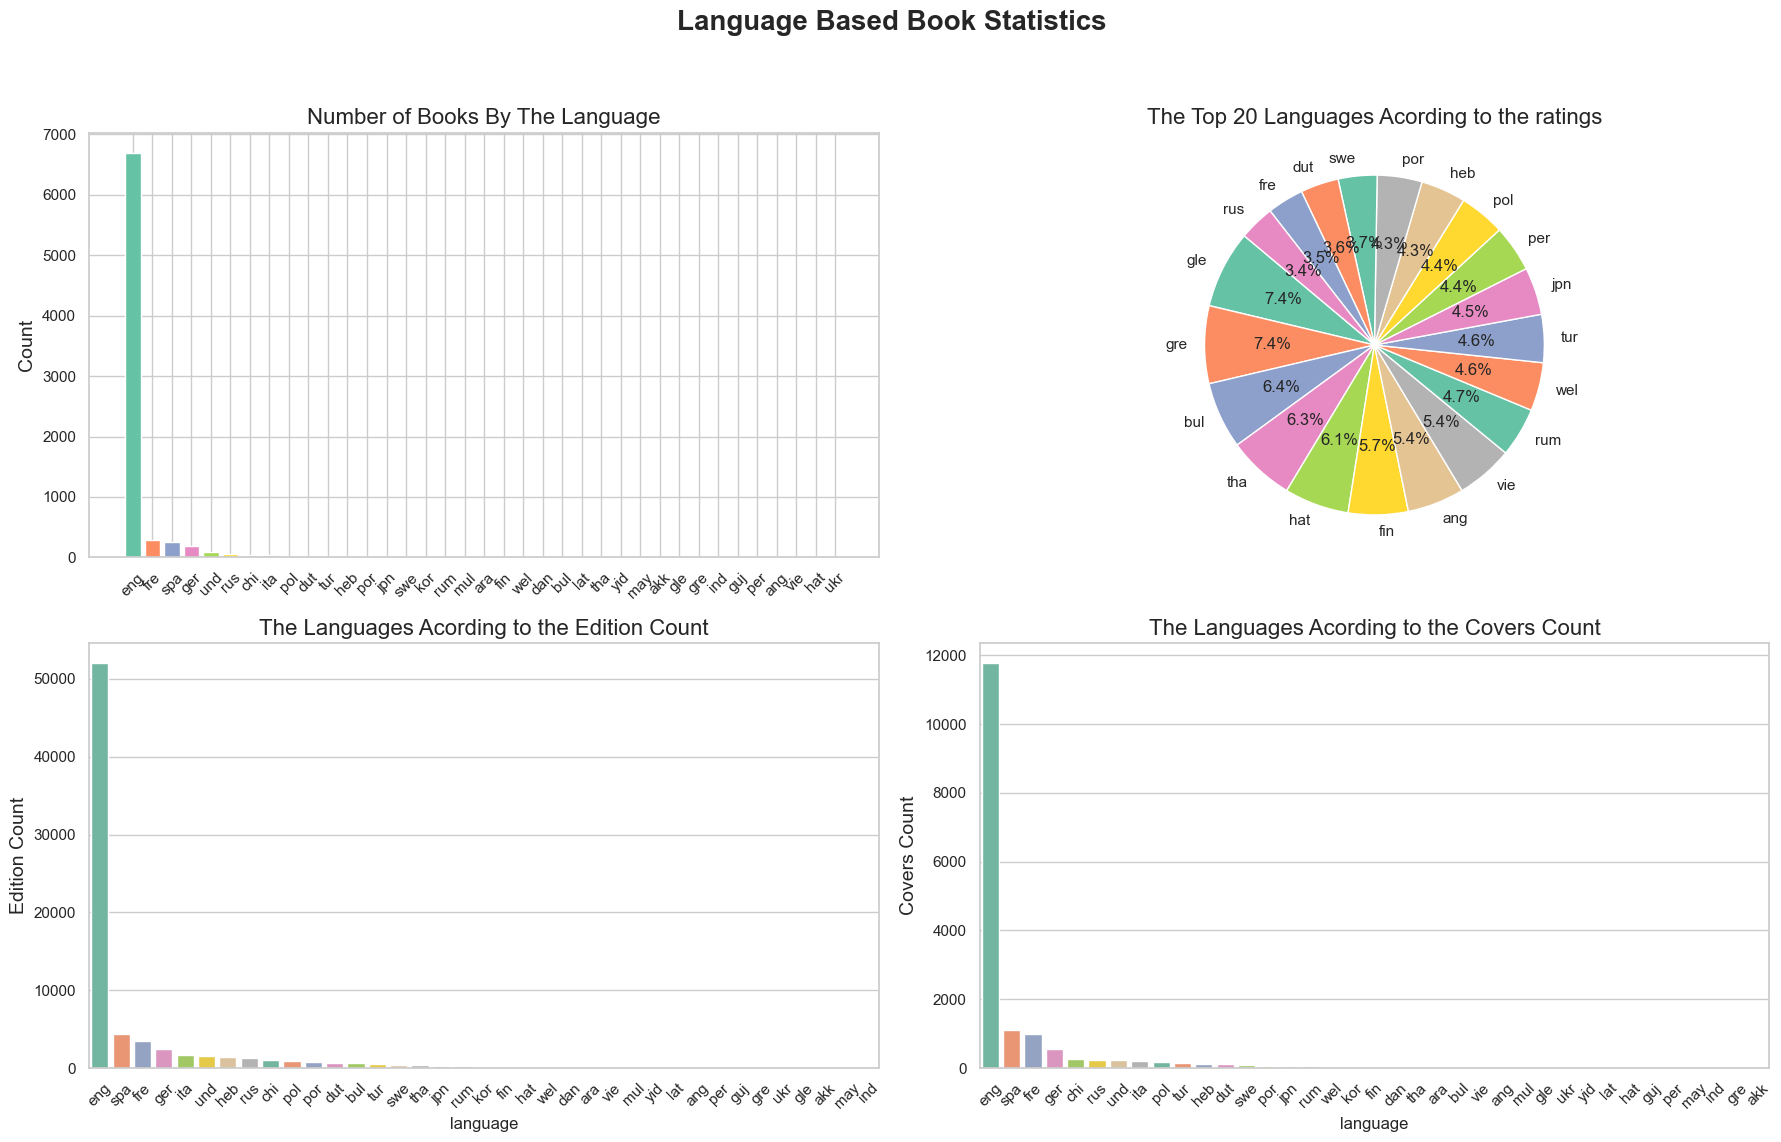

In [52]:
# Set the Seaborn style for the plots to 'whitegrid'
sns.set(style="whitegrid")
# Choose a color palette for the whole styling
colors =sns.color_palette("Set2")

# Create a 2x2 subplot with a large figure size
fig, axs =plt.subplots(2, 2, figsize=(18, 12))
# Set the main title for the entire figure
fig.suptitle('Language Based Book Statistics', fontsize=20, fontweight='bold')

# Subplot 1: Bar chart of book count for each language
axs[0, 0].bar(language_counts.index, language_counts.values, color=colors)
axs[0, 0].set_title("Number of Books By The Language", fontsize=16)
axs[0, 0].set_ylabel("Count", fontsize=14)
axs[0, 0].tick_params(axis='x', labelrotation=45)  # Rotate x-axis labels for readability

# Subplot 2: Pie chart of language ratings
# Get only the top 20 ratings Languages
lang_rating =lang_rating.head(20)
axs[0, 1].pie(lang_rating.values, labels=lang_rating.index, autopct='%1.1f%%', colors=colors, startangle=140)
axs[0, 1].set_title("The Top 20 Languages Acording to the ratings", fontsize=16)

# Subplot 3: Bar chart of edition count for each language
lang_edition = df.groupby('language')['edition_count'].sum().sort_values(ascending=False)
sns.barplot(x=lang_edition.index, y=lang_edition.values, ax=axs[1, 0], palette=colors)
axs[1, 0].set_title("The Languages Acording to the Edition Count", fontsize=16)
axs[1, 0].set_ylabel("Edition Count", fontsize=14)
axs[1, 0].tick_params(axis='x', labelrotation=45) # Rotate x-axis labels

# Subplot 4: Bar chart of covers count for each language
lang_cover = df.groupby('language')['covers_count'].sum().sort_values(ascending=False)
sns.barplot(x=lang_cover.index, y=lang_cover.values, ax=axs[1, 1], palette=colors)
axs[1, 1].set_title("The Languages Acording to the Covers Count", fontsize=16)
axs[1, 1].set_ylabel("Covers Count", fontsize=14)
axs[1, 1].tick_params(axis='x', labelrotation=45)

# Adjust layout to prevent overlap and leave space for the suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Display the entire figure
plt.show()

### Subplot to collect 4 different plots for Authors Analysis As the plots shows the Relationship of  each Author
### and each of the Average rating and the edition counts and the covers counts and also plot to show the count of each Author

C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2421619546.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=author_edition.index, x=author_edition.values, ax=axs[1, 0], palette=color3)
C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2421619546.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=author_cover.index, x=author_cover.values, ax=axs[1, 1],  palette=color4)


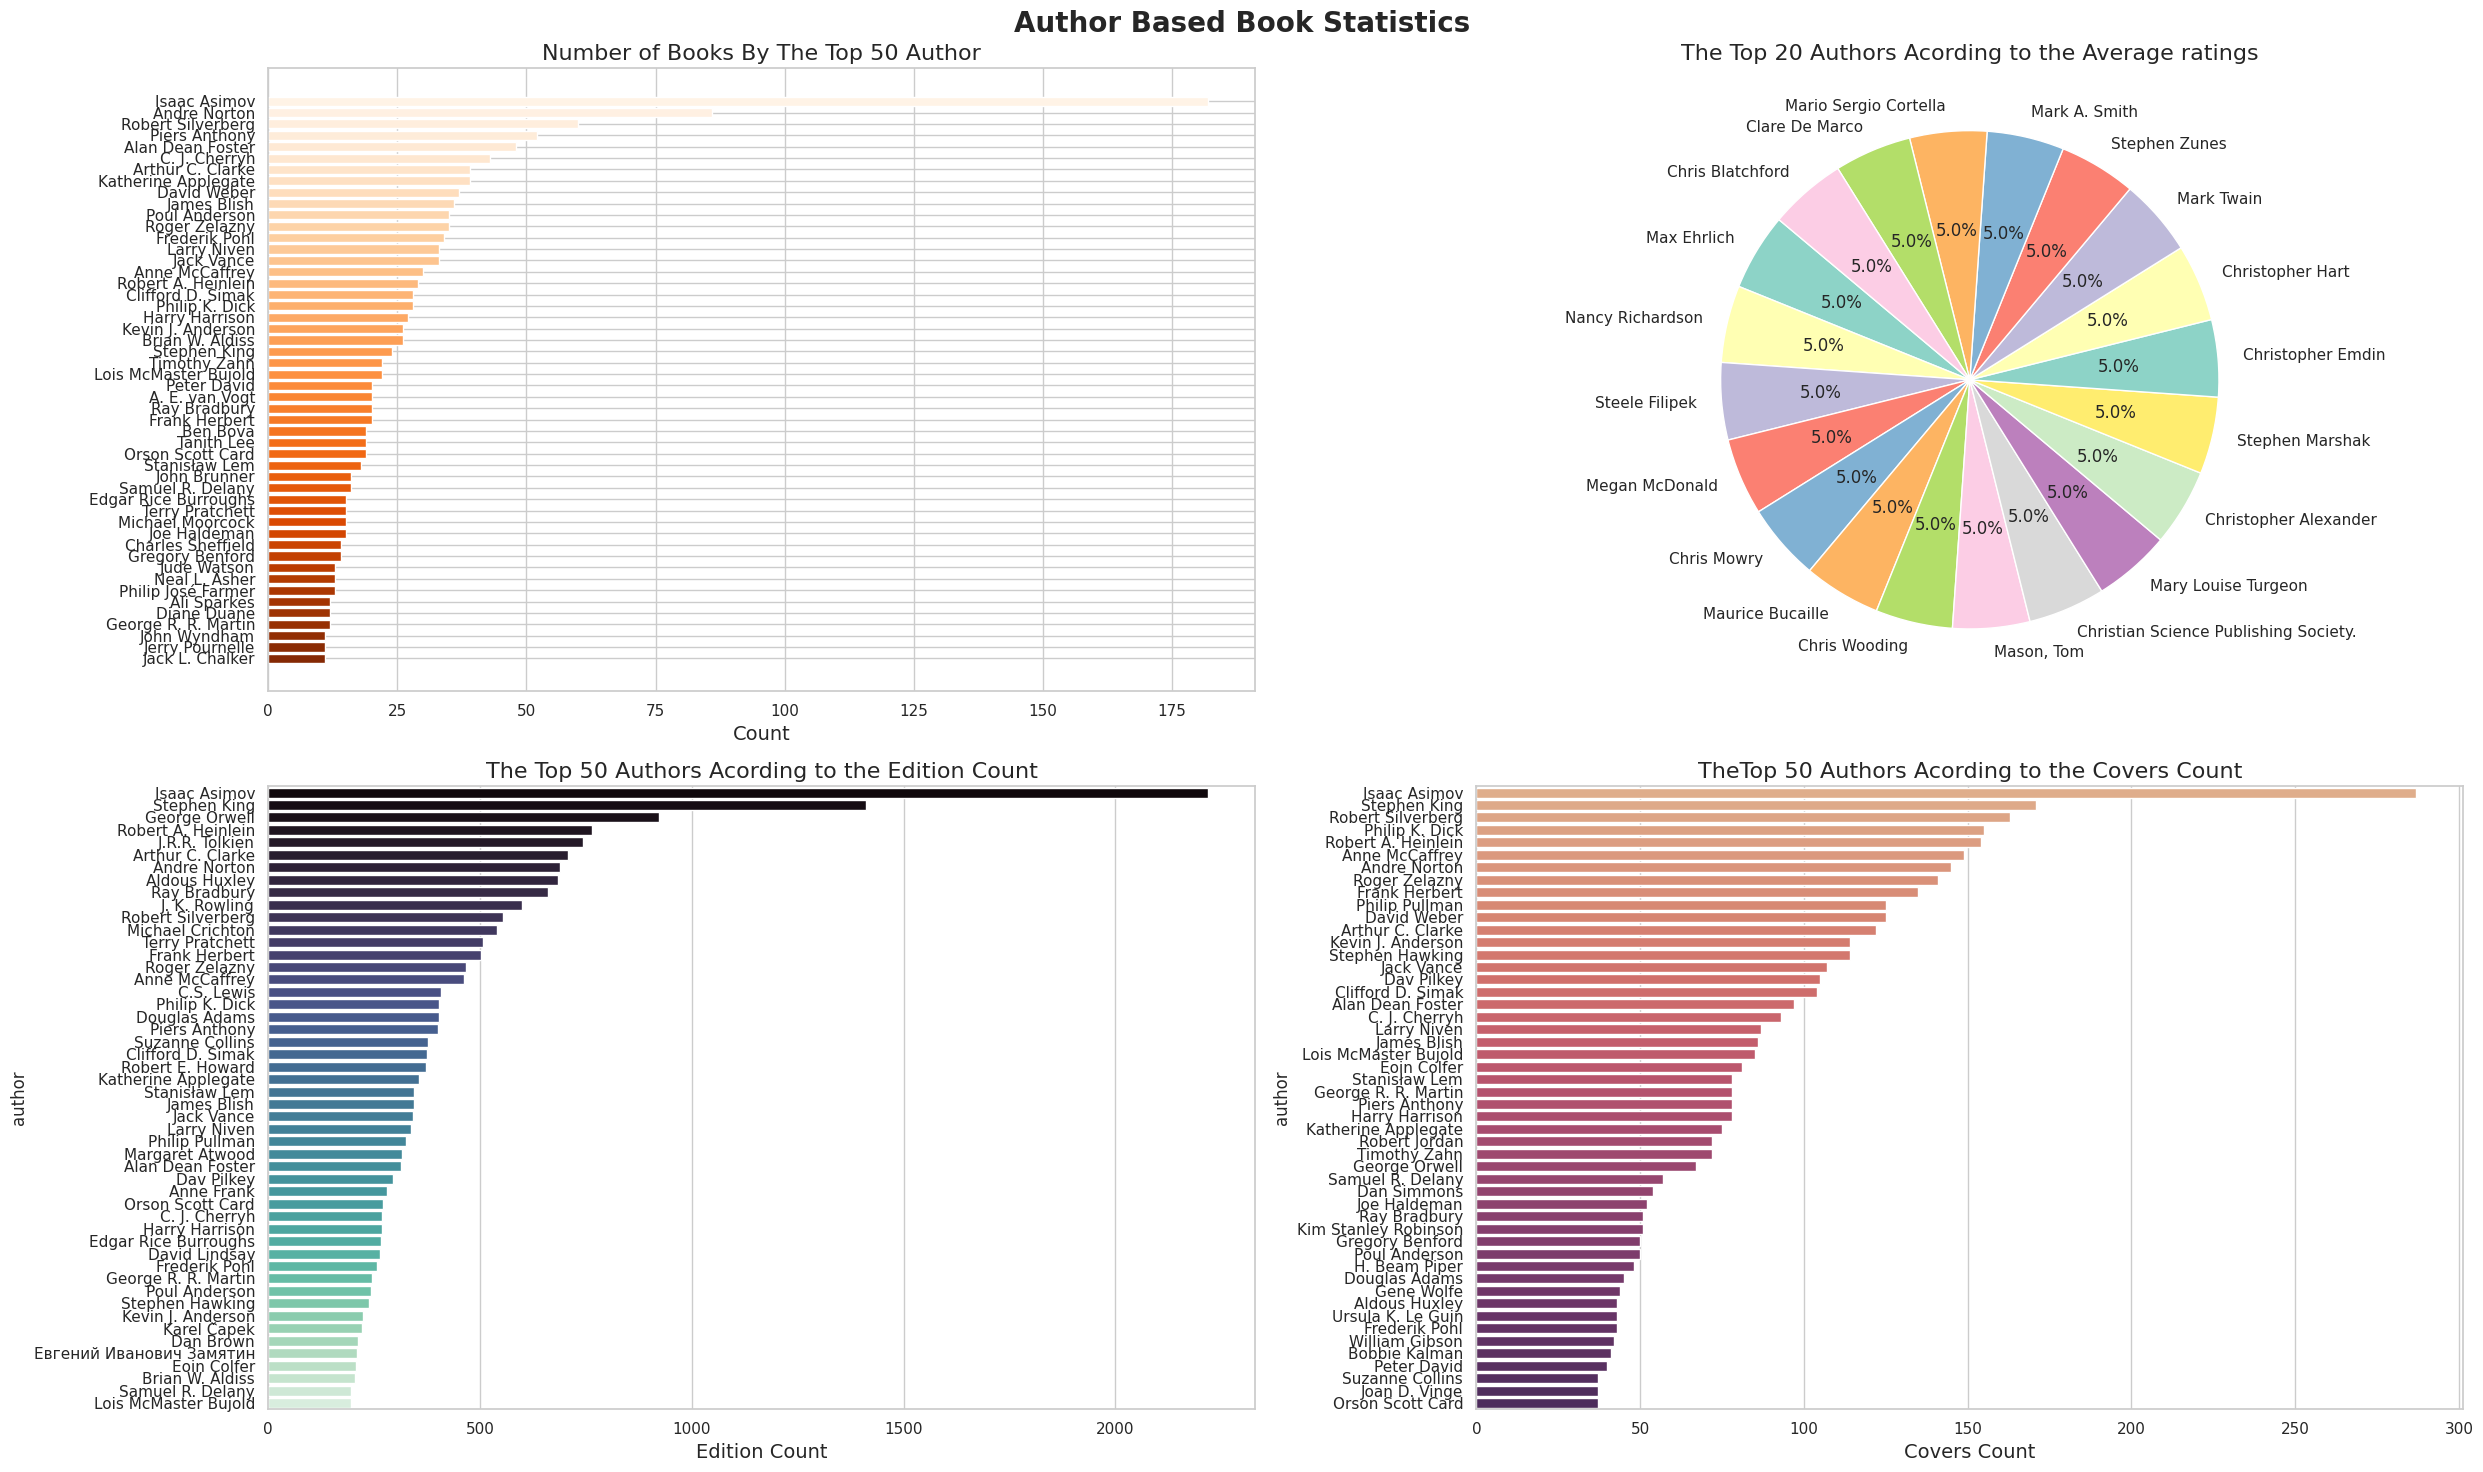

In [53]:
# Set the default font for all plots to 'DejaVu Sans' because there languages like chinese
plt.rcParams['font.family'] = 'DejaVu Sans'
# Get the top 50 authors with the most published books numbers
author_count =df['author'].value_counts().head(50)
# Set the colors for the author_count plot As for each Author a different color
color1 =sns.color_palette("Oranges", len(author_count))

# Calculate the top 20 authors by average rating
author_rating = df.groupby('author')['average_rating'].mean().sort_values(ascending=False).head(20)
# Set the colors for the author_rating plot As for each Author a different color
color2 =sns.color_palette("Set3", len(author_rating))

# Calculate the top 50 authors by total edition count
author_edition = df.groupby('author')['edition_count'].sum().sort_values(ascending=False).head(50)
# Set the colors for the author_edition plot As for each Author a different color
color3 =sns.color_palette("mako", len(author_edition))

# Calculate the top 50 authors by total covers count
author_cover = df.groupby('author')['covers_count'].sum().sort_values(ascending=False).head(50)
# Set the colors for the author_cover plot As for each Author a different color
color4 =sns.color_palette("flare", len(author_cover))

# Create a 2x2 subplot figure
fig, axs =plt.subplots(2, 2, figsize=(25, 15))
# Add a main title for the entire figure
fig.suptitle('Author Based Book Statistics', fontsize=20, fontweight='bold')
# Adjust space between subplots
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Subplot 1: Horizontal bar chart of book count for each author
axs[0, 0].barh(author_count.index, author_count.values, color=color1)
axs[0, 0].set_title("Number of Books By The Top 50 Author", fontsize=16)
axs[0, 0].set_xlabel("Count", fontsize=14)
axs[0, 0].invert_yaxis()  # Invert y-axis for better visual ordering

# Subplot 2: Pie chart of average rating for each author
axs[0, 1].pie(author_rating.values, labels=author_rating.index, autopct='%1.1f%%', colors=color2, startangle=140)
axs[0, 1].set_title("The Top 20 Authors Acording to the Average ratings", fontsize=16)

# Subplot 3: Bar chart (Horizontal Barplot) of edition count for each author
sns.barplot(y=author_edition.index, x=author_edition.values, ax=axs[1, 0], palette=color3)
axs[1, 0].set_title("The Top 50 Authors Acording to the Edition Count", fontsize=16)
axs[1, 0].set_xlabel("Edition Count", fontsize=14)

# Subplot 4: Bar chart (Horizontal Barplot) of cover count for each author
sns.barplot(y=author_cover.index, x=author_cover.values, ax=axs[1, 1],  palette=color4)
axs[1, 1].set_title("TheTop 50 Authors Acording to the Covers Count", fontsize=16)
axs[1, 1].set_xlabel("Covers Count", fontsize=14)

# Automatically adjust layout to avoid overlap
plt.tight_layout()
# Show the final figure
plt.show()

### Horizontal barplot to show the top 100 Frequent Subjects

C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2326262622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=topp_subjects.index, x=topp_subjects.values, palette="Spectral")


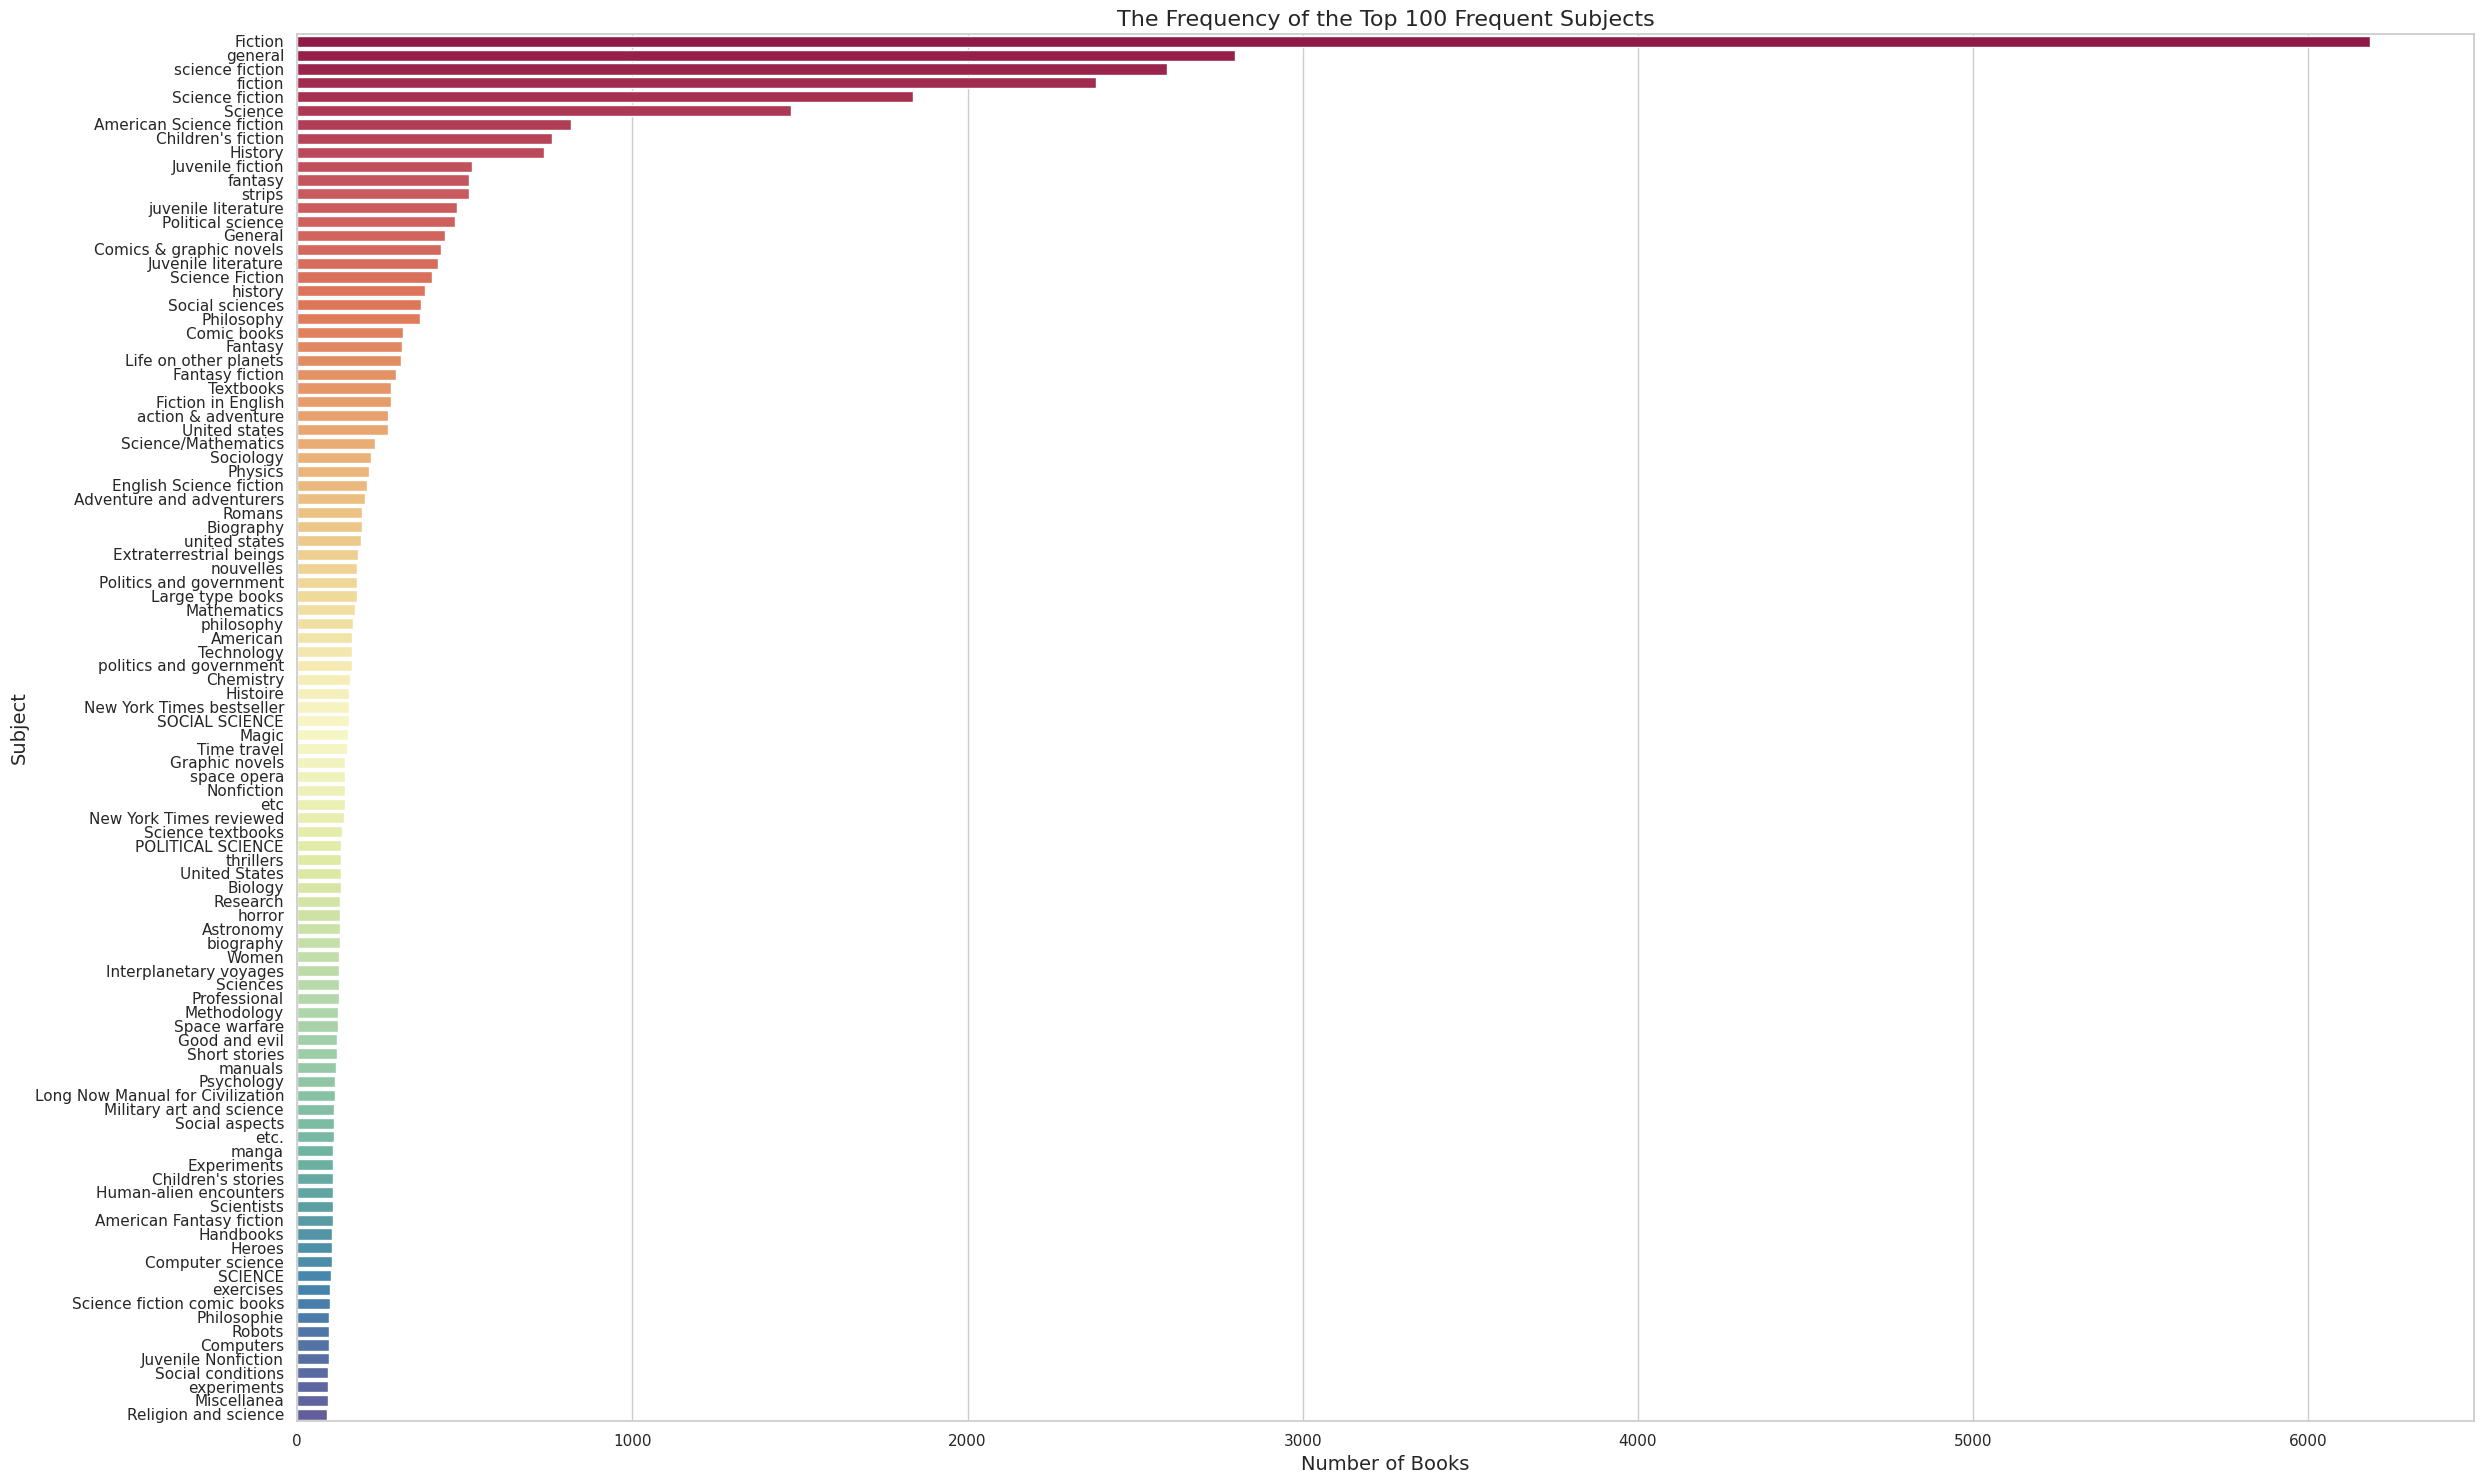

In [54]:
# Get the top 100 most frequent subjects from the flattened subjects series
topp_subjects =flat_subjects.value_counts().head(100)
# Set the figure size and make it big for better readability
plt.figure(figsize=(25, 15))
# Create a horizontal barplot showing the frequency of each subject
sns.barplot(y=topp_subjects.index, x=topp_subjects.values, palette="Spectral")
# Set the title of the plot
plt.title("The Frequency of the Top 100 Frequent Subjects", fontsize=16)
# Set the title of the x-axis
plt.xlabel("Number of Books", fontsize=14)
# Set the title of the y-axis
plt.ylabel("Subject", fontsize=14)
# Adjust layout to prevent label overlapping
plt.tight_layout()
# Display the final plot
plt.show()

### Horizontal barplot to show the Frequent of the Genres

C:\Users\KING\AppData\Local\Temp\ipykernel_20420\3125166712.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=genres.index, x=genres.values, palette="plasma")


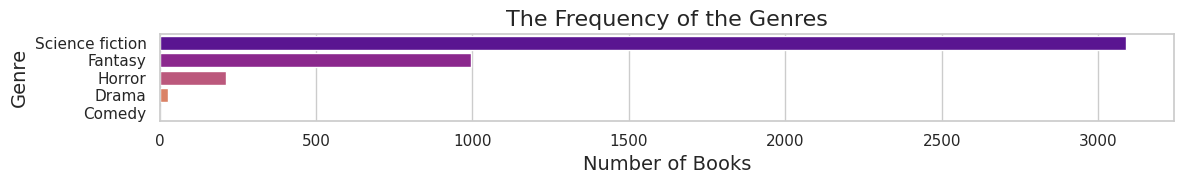

In [55]:
# Count the frequency of each genre in the exploded 'genres' column
genres =df_exploded['genres'].value_counts()
# Set the figure size dynamically based on the number of genres for better readability
plt.figure(figsize=(12, len(genres) // 2))
# Create a horizontal barplot showing the frequency of each genre
sns.barplot(y=genres.index, x=genres.values, palette="plasma")
# Set the title of the plot
plt.title("The Frequency of the Genres", fontsize=16)
# Set the title of the x-axis
plt.xlabel("Number of Books", fontsize=14)
# Set the title of the y-axis
plt.ylabel("Genre", fontsize=14)
# Adjust layout to prevent label overlapping
plt.tight_layout()
# Display the final plot
plt.show()

### Line Chart to show how many Books were published in each publish date

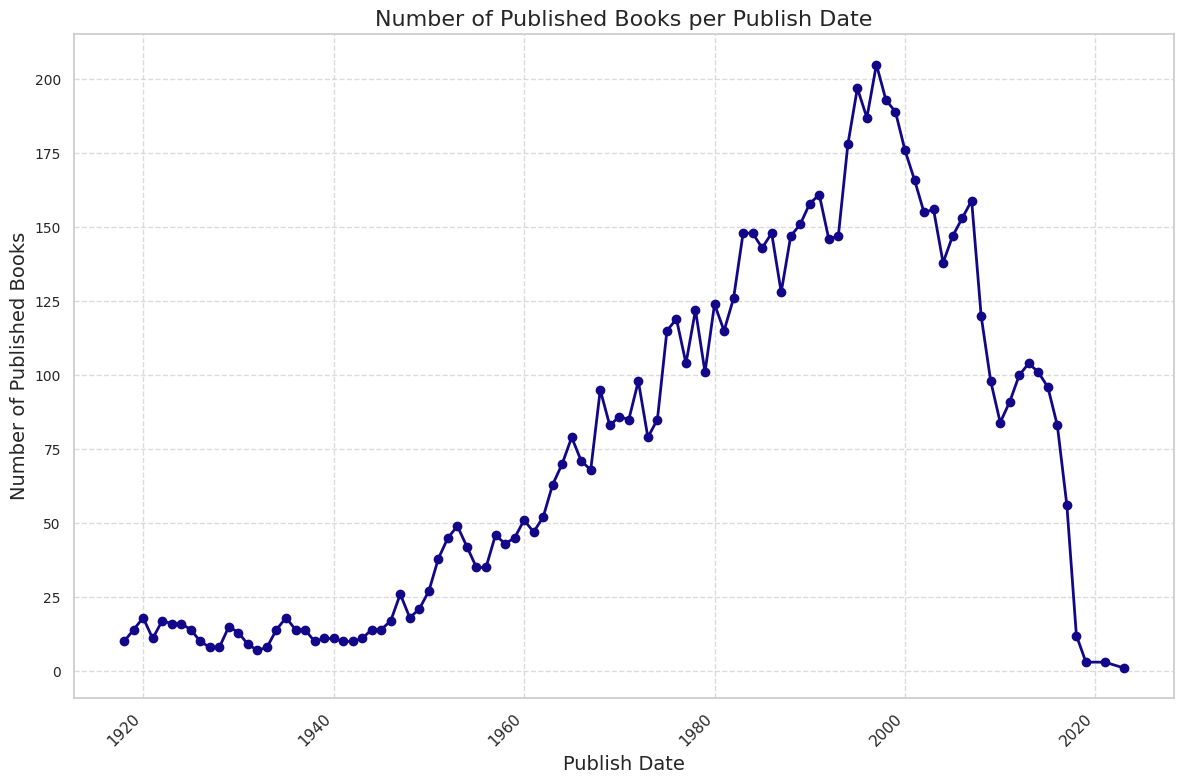

In [56]:
# Count how many books were published for each publish date and sort by date
publish_date_count =df['publish_date'].value_counts().sort_index()
# Create a color palette with as many colors as there are unique publish dates
pallete =sns.color_palette("plasma", n_colors=len(publish_date_count))
# Set the figure size for the plot
plt.figure(figsize=(12, 8))
# Plot the number of books published per date as a line chart
plt.plot(publish_date_count.index, publish_date_count.values, marker='o', linestyle='-', linewidth=2, color=pallete[0])
# Set the title of the x-axis
plt.xlabel("Publish Date", fontsize=14)
# Set the title of the y-axis
plt.ylabel("Number of Published Books", fontsize=14)
# Set the title of the plot
plt.title("Number of Published Books per Publish Date", fontsize=16)
# Add grid lines to the plot
plt.grid(True, linestyle='--', alpha=0.7)
# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
# Set font size for y-axis ticks
plt.yticks(fontsize=10)
# Adjust layout to prevent overlap
plt.tight_layout()
# Display the Plot
plt.show() 

## Visualize The Kmeans Analysis
### Subplot that consist of 2 plots one to show the clusters in 2D space using PCA components and the second plot to show the count of Books in each
### Cluster

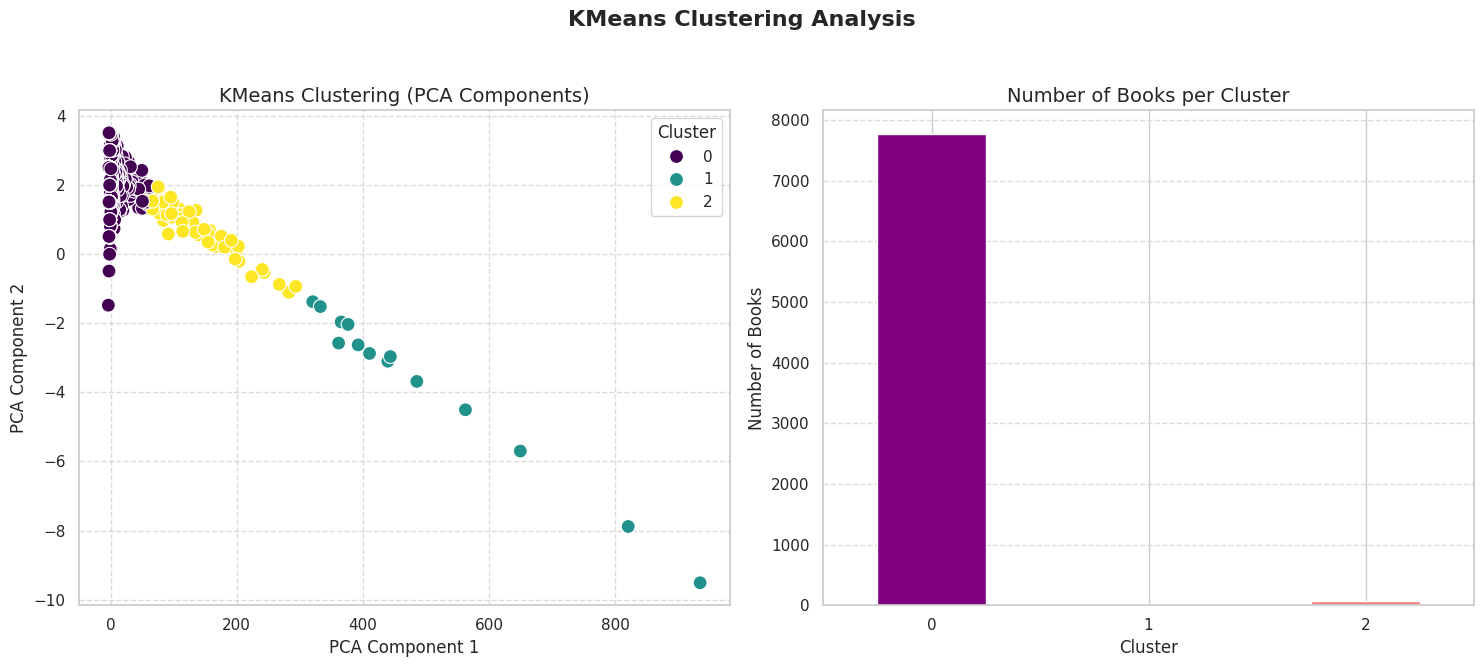

In [57]:
# Set the default font for all plots to 'DejaVu Sans' because there languages like chinese
plt.rcParams['font.family'] = 'DejaVu Sans'
# Create a figure with 2 subplots Consist of 1 row and 2 columns
fig, axes =plt.subplots(1, 2, figsize=(15, 7))
# Set a title for the entire figure
fig.suptitle('KMeans Clustering Analysis', fontsize=16, fontweight='bold')

# Plot the clusters in 2D space using PCA components
sns.scatterplot(ax=axes[0], x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], palette='viridis', s=100)
axes[0].set_title('KMeans Clustering (PCA Components)', fontsize=14)
axes[0].set_xlabel('PCA Component 1', fontsize=12)
axes[0].set_ylabel('PCA Component 2', fontsize=12)
axes[0].legend(title='Cluster')  # Add legend to the plot
axes[0].grid(True, linestyle='--', alpha=0.7) # Add grid to the plot

# Count the number of books in each cluster
cluster_count =df['Cluster'].value_counts().sort_index()
# Define custom colors for each cluster bar
cluster_colors ={0: 'purple', 1: 'skyblue', 2: 'lightcoral'}
# Get the list of colors based on cluster index
colors =[cluster_colors[i] for i in cluster_count.index]
# Plot a bar chart showing the number of books per cluster
cluster_count.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('Number of Books per Cluster', fontsize=14)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Number of Books', fontsize=12)
axes[1].set_xticklabels(cluster_count.index, rotation=0)  # No rotation for x-axis labels
axes[1].grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines

# Adjust the layout and add spacing for the title
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Display the plots
plt.show()

### we can see that the second (Right) plot only show the number of books for the Cluster 0 and not for cluster 1 or 2
### and that because the number Books in Clusters 1 and 2 are very small to be visible comparing with the number of Books in Cluster 0

In [58]:
# Print the number of Books in Each Cluster
print(cluster_count)

Cluster
0    7770
1      14
2      62
Name: count, dtype: int64


## In Continue with The Kmeans Analysis Visualization
### Create Subplot Consist of 2 plots one to show the distribution of the average rating for each cluster and the second plot to show
### the distribution of the rating count for each Cluster

C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2760032620.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Cluster', y='average_rating', data=df, palette='YlGnBu')
C:\Users\KING\AppData\Local\Temp\ipykernel_20420\2760032620.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Cluster', y='rating_count', data=df, palette='OrRd')


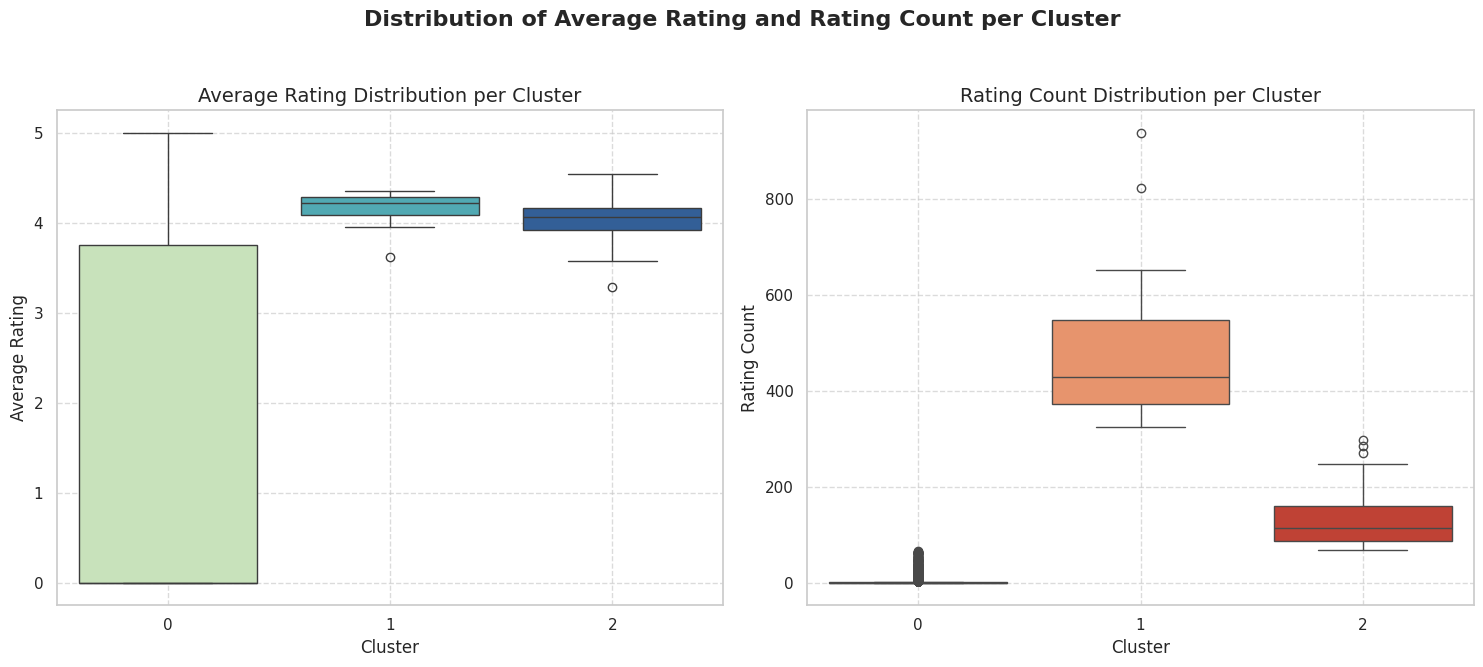

In [59]:
# # Set the default font for all plots to 'DejaVu Sans' because there languages like chinese
plt.rcParams['font.family'] = 'DejaVu Sans'
# Create a figure Consist of 2 subplots side by side
fig, axes =plt.subplots(1, 2, figsize=(15, 7))
# Set a title for the entire figure
fig.suptitle('Distribution of Average Rating and Rating Count per Cluster', fontsize=16, fontweight='bold')

# Create a boxplot showing average rating distribution for each cluster
sns.boxplot(ax=axes[0], x='Cluster', y='average_rating', data=df, palette='YlGnBu')
axes[0].set_title('Average Rating Distribution per Cluster', fontsize=14)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Average Rating', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.7)  # Add dashed gridlines

# Create a boxplot showing rating count distribution for each cluster
sns.boxplot(ax=axes[1], x='Cluster', y='rating_count', data=df, palette='OrRd')
axes[1].set_title('Rating Count Distribution per Cluster', fontsize=14)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Rating Count', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.7)  # Add dashed gridlines

# Adjust layout and make room for the main title
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Display the plots
plt.show()

### Visualize the Apriori algorithm
### Make a directed graph to represent association rules and Add a directed edge from antecedent to consequent with lift as weight and label

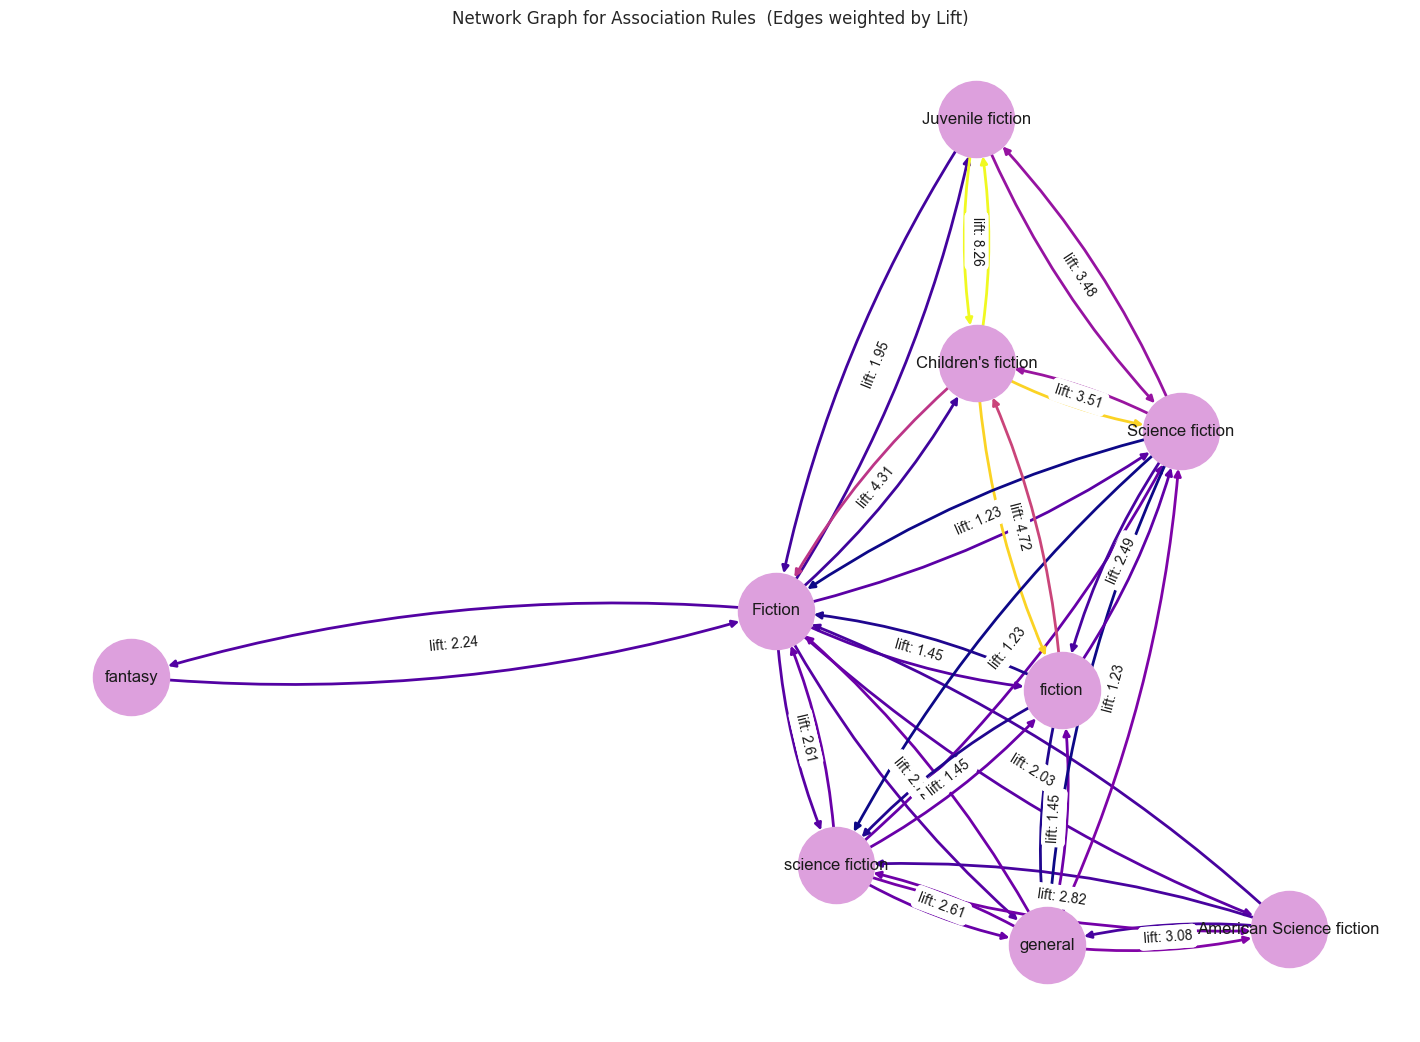

In [60]:
# Import the networkx library for creating and analyzing graphs
import networkx as nx

# Create a directed graph to represent association rules
G =nx.DiGraph()
# Iterate over each rule in the DataFrame
for _, row in rules.iterrows():
    # For each antecedent in the rule
    for ant in row['antecedents']:
        # For each consequent in the rule
        for con in row['consequents']:
            # Add a directed edge from antecedent to consequent with lift as weight and label
            G.add_edge(ant, con, weight=row['lift'], label=f"lift: {row['lift']:.2f}")

# Set the size of the plot
plt.figure(figsize=(14, 10))
# Compute the layout for the graph nodes using the spring layout
pos =nx.spring_layout(G, k=1.5, seed=42)
# Get the edges with associated data (like weight and label)
edges =G.edges(data=True)
# Extract weights from the edges to use for edge coloring
weights =[edata['weight'] for _, _, edata in edges]
# Draw the graph
nx.draw(G, pos, with_labels=True, node_color="plum", node_size=3000, font_size=12, edge_color=weights, edge_cmap=plt.cm.plasma, width=2.0,
        arrows=True, connectionstyle='arc3,rad=0.1')
# Create a dictionary of edge labels using lift values
edge_labels = {(u, v): d['label'] for u, v, d in edges}
# Draw edge labels (lift values) on the graph
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
# Set the title of the plot
plt.title("Network Graph for Association Rules  (Edges weighted by Lift)")

# Display the Plot
plt.show()

### Create a Matrix Plot to show the Lift Values Between the Antecedents and the Consequents

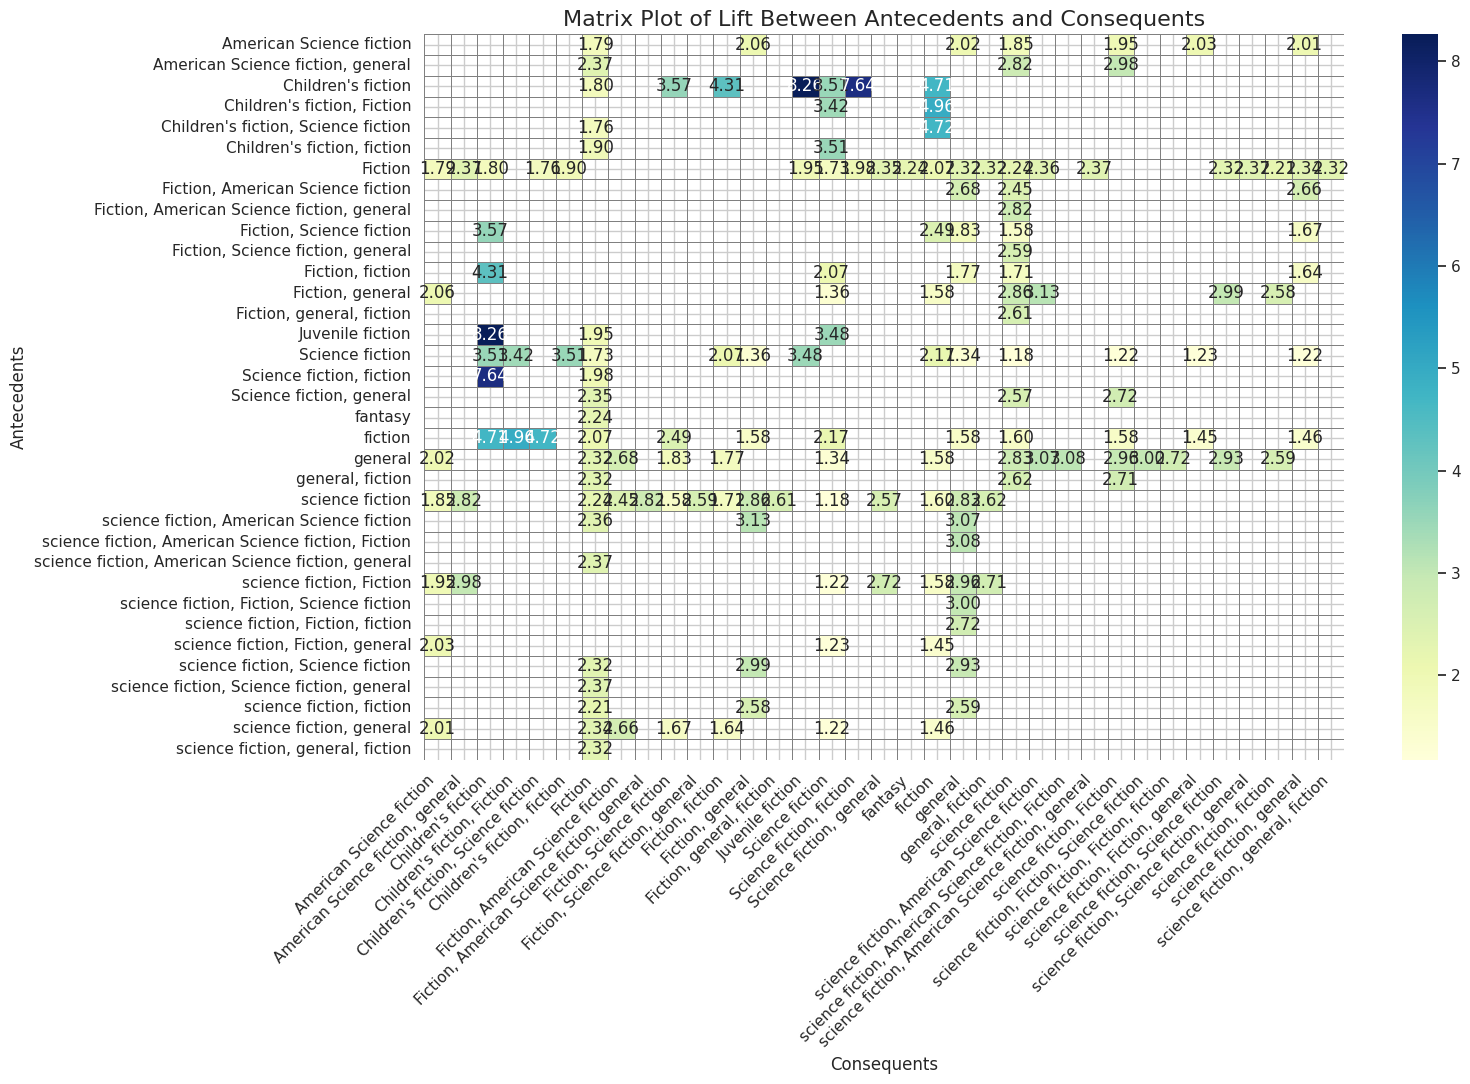

In [61]:
# Convert the 'antecedents' frozenset to a comma-separated string for better readability
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
# Convert the 'consequents' frozenset to a comma-separated string for better readability
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

# Create a pivot table where the rows are antecedents, columns are consequents, and values are lift scores
matrix = rules.pivot_table(index='antecedents_str', columns='consequents_str', values='lift')

# Set the size of the figure for the heatmap
plt.figure(figsize=(16, 11))
# Plot the heatmap of lift values between antecedents and consequents
sns.heatmap(matrix, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=.5, linecolor='gray')

# Set the title and axis labels for the plot
plt.title('Matrix Plot of Lift Between Antecedents and Consequents', fontsize=16)
plt.xlabel('Consequents', fontsize=12)
plt.ylabel('Antecedents', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis tick labels for better visibility
plt.yticks(rotation=0)  # Keep y-axis labels horizontal
# Adjust the layout to prevent clipping of labels and titles
plt.tight_layout()
# Display the plot
plt.show()

### Creating an interactive scatter plot using Plotly Express to show All the Possible Information of the Association rules
### like showing the Antecedents and Consequents names and the support and the confidence and lift values of them and all that will be shown
### when you just put the mouse on any point of the points

In [62]:
# Importing Plotly Express for interactive plotting
import plotly.express as px

# Creating a copy of the rules DataFrame to avoid modifying the original
rules_plot = rules.copy()
# Converting the 'antecedents' from frozenset to a comma-separated string for display
rules_plot['antecedents'] = rules_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
# Converting the 'consequents' from frozenset to a comma-separated string for display
rules_plot['consequents'] = rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))

# Creating an interactive scatter plot using Plotly Express
fig = px.scatter(
    rules_plot,    # DataFrame containing the association rules
    x='support',   # x-axis represents the support of the rule
    y='confidence',   # y-axis represents the confidence of the rule
    size='lift',   # Bubble size reflects the lift value
    color='lift',   # Color intensity also reflects the lift value
    hover_data={    # Data to be displayed when hovering over a point
        'antecedents': True,
        'consequents': True,
        'support': True,
        'confidence': True,
        'lift': True
    },
    title='Interactive Scatter Plot of Association Rules',  # Title of the plot
    labels={   # Labels for axes and hover info
        'support': 'Support',
        'confidence': 'Confidence',
        'lift': 'Lift',
        'antecedents': 'Antecedents',
        'consequents': 'Consequents'
    },
    color_continuous_scale='Viridis'  # Color palette for lift values
)

# Update layout: Set width, height, and title font size
fig.update_layout(
    width=1000,   
    height=700,   
    title_font_size=24
)

# Display the interactive plot
fig.show()

# =========== Data Storing ===========

In [63]:
# ! pip install pymongo

## Store the cleaned data 

In [64]:
from pymongo import MongoClient

# Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")

# Select the database
db = client["BOOKS"]

# Select the collection
collection = db["CLEANED_BOOKS"]

# Convert the DataFrame to a list of dictionaries
data = df.to_dict(orient="records")

# Insert multiple documents into the collection
collection.insert_many(data)

print("Data has been successfully stored!")


Data has been successfully stored!


## Store the Association Rules

In [65]:
# Select the collection
collection = db["BOOKS_Association_Rules"]

# Check if the 'rules' DataFrame is not empty
if not rules.empty:
    # Convert frozensets in 'antecedents' and 'consequents' columns to lists
    rules['antecedents'] = rules['antecedents'].apply(lambda x: list(x))
    rules['consequents'] = rules['consequents'].apply(lambda x: list(x))

    # Convert the Association Rules DataFrame to a list of dictionaries
    ass_rules = rules.to_dict(orient="records")

    # Insert multiple documents into the collection
    insert_result = collection.insert_many(ass_rules)

    # Check if the insertion was successful
    if insert_result.inserted_ids:
        print(f"{len(insert_result.inserted_ids)} rules have been successfully stored!")
    else:
        print("Failed to insert data.")
else:
    print("No data to insert.")

# Close the MongoDB client
client.close()

print("Data has been successfully stored!")

166 rules have been successfully stored!
Data has been successfully stored!


# ===========Streamlit_bouns============

### We wrote the bonus here as a comment because it doesn't work in Jupiter, but rather as a py file.

In [ ]:
'''

import streamlit as st
from pymongo import MongoClient
import base64
from PIL import Image
import pandas as pd
import plotly.express as px
import re

# a very important resource
@st.cache_resource
def init_connection():
    client = MongoClient("mongodb://localhost:27017/")
    return client

client = init_connection()
db = client["BOOKS"]
books_collection = db["CLEANED_BOOKS"]
books_analysis = db["BOOKS_Association_Rules"]

st.sidebar.title("The Main List")

# background music
audio_file = open(r'C:\Users\DELL\Downloads\ambient-fantasy-314682.mp3', 'rb')
audio_bytes = audio_file.read()

# Encode the audio file to Base64
encoded_audio = base64.b64encode(audio_bytes).decode()

# Create an HTML audio tag with autoplay, loop, and hidden attributes
background_audio = f"""
    <audio autoplay loop hidden>
        <source src="data:audio/mp3;base64,{encoded_audio}" type="audio/mp3">
    </audio>
"""
# Inject the HTML into the Streamlit app
st.markdown(background_audio, unsafe_allow_html=True)

# make the sidebar and the header in the naive blue color
st.markdown(
    """
    <style>
    [data-testid="stSidebar"] {
    background-color: #001f3f; /* naive blue color code */
    color: white; /* change the writing to be white */
    }
    
    [data-testid="stSidebar"] * {
        color: white !important; /* it must be white  */
    }

    /* change header color */
    header[data-testid="stHeader"] {
        background-color: #001f3f;
    }

    /* hide the line between the header and the contact */
    header[data-testid="stHeader"]::after {
        background: none;
    }
    </style>
    """,
    unsafe_allow_html=True
)

options = ["Books", "Search Books" , "Analysis", "Visualization"]

# display the books
def show_books():
    st.title("BOOKS")

    # background color
    base_page = """
    <style>
    [data-testid="stAppViewContainer"] {
        background: linear-gradient(to right, #ff7e5f, #feb47b, #86a8e7, #91eae4);
    }
    </style>
    """
    st.markdown(base_page, unsafe_allow_html=True)

    #number of pages (20 books in one page)
    num_pages = 393

    # Get the current page number from session state, initialize to 1 if not present
    if "current_page" not in st.session_state:
        st.session_state["current_page"] = 1

    def next_page():
        if st.session_state["current_page"] < num_pages:
            st.session_state["current_page"] += 1

    def prev_page():
        if st.session_state["current_page"] > 1:
            st.session_state["current_page"] -= 1

    col1, col2 = st.columns([1, 1])
    with col1:
        st.button("Previous Page", on_click=prev_page)
    with col2:
        st.button("Next Page", on_click=next_page)

    st.write(f"Page {st.session_state['current_page']} of {num_pages}")

    # Calculate the number of documents to skip
    skip_amount = (st.session_state["current_page"] - 1) * 20

    # Fetch books for the current page
    books_on_page = books_collection.find().skip(skip_amount).limit(20)

    for book in books_on_page:
        with st.expander(book.get("title", "Untitled")):
            st.write(f"Title: {book.get('title', 'N/A')}")
            st.write(f"Author: {book.get('author', 'N/A')}")
            st.write(f"Publish Date: {book.get('publish_date', 'N/A')}")
            st.write(f"Language: {book.get('language', 'N/A')}")
            st.write(f"Subjects: {', '.join(book.get('cleaned_subjects', []))}")
            st.write(f"Pages Number: {book.get('num_pages', 'N/A')}")
            st.write(f"Edition Count: {book.get('edition_count', 'N/A')}")
            st.write(f"Covers Count: {book.get('covers_count', 'N/A')}")
            st.write(f"Average Rating: {book.get('average_rating', 'N/A')}")
            st.write(f"Rating Count: {book.get('rating_count', 'N/A')}")
            st.write(f"URL: {book.get('url', 'N/A')}")

# search for books
def show_search_books():

    # background color
    base_page = """
    <style>
    [data-testid="stAppViewContainer"] {
        background: linear-gradient(to left, #92a8d1, #034f84, #f7cac9, #f7786b);
    }
    </style>
    """
    st.markdown(base_page, unsafe_allow_html=True)
    # search for book by title
    search_term = st.text_input("Search by Title:")

    # get the unique values for the 'publish date' and 'language'
    publish_dates = books_collection.distinct("publish_date")
    languages = books_collection.distinct("language")

    # Extract unique cleaned subjects from MongoDB
    subjects = books_collection.aggregate([
        {"$project": {"subjects": {"$split": ["$subjects", ","]}}},
        {"$unwind": "$subjects"},
        {"$project": {"subject": {"$trim": {"input": {"$toLower": "$subjects"}}}}},
        {"$match": {"subject": {"$ne": ""}}},
        {"$group": {"_id": "$subject"}}
    ])

    def is_valid_subject(subj):
        if not subj:
            return False
        cleaned_subj = re.sub(r'[\d\-\&\(\)\.\*]+', '', subj).strip()
        return (
                len(cleaned_subj) >= 3 and
                sum(c.isalpha() for c in cleaned_subj) >= 3
        )
    unique_subjects = sorted({doc["_id"] for doc in subjects if is_valid_subject(doc.get("_id", ""))})
    # choices keys
    selected_date = st.selectbox("Filter by Publish Date:", ["All"] + list(publish_dates))
    selected_language = st.selectbox("Filter by Language:", ["All"] + list(languages))
    selected_subject = st.selectbox("Filter by Subject:", ["All"] + unique_subjects)

    # Build MongoDB query based on search and filters
    query = {}
    if search_term:
        query["title"] = {"$regex": search_term, "$options": "i"}  # Case-insensitive search
    if selected_date != "All":
        query["publish_date"] = selected_date
    if selected_language != "All":
        query["language"] = selected_language
    if selected_subject != "All":
        query["subjects"] = {"$regex": f"(?i){re.escape(selected_subject)}"}

    # Retrieve books based on the query
    found_books = books_collection.find(query)

    # Display search results and details on expand
    for book in found_books:
        with st.expander(book.get("title", "Untitled")):
            st.write(f"Title: {book.get('title', 'N/A')}")
            st.write(f"Author: {book.get('author', 'N/A')}")
            st.write(f"Publish Date: {book.get('publish_date', 'N/A')}")
            st.write(f"Language: {book.get('language', 'N/A')}")
            st.write(f"Subjects: {', '.join(book.get('cleaned_subjects', []))}")
            st.write(f"Pages Number: {book.get('num_pages', 'N/A')}")
            st.write(f"Edition Count: {book.get('edition_count', 'N/A')}")
            st.write(f"Covers Count: {book.get('covers_count', 'N/A')}")
            st.write(f"Average Rating: {book.get('average_rating', 'N/A')}")
            st.write(f"Rating Count: {book.get('rating_count', 'N/A')}")
            st.write(f"URL: {book.get('url', 'N/A')}")

# display the association rules
def show_analysis():

    # background color
    base_page = """
        <style>
        [data-testid="stAppViewContainer"] {
            background: linear-gradient(to right, #b2b2b2, #f4e1d2, #f18973, #bc5a45);
        }
        </style>
        """
    st.markdown(base_page, unsafe_allow_html=True)

    st.title("ASSOCIATION RULES")
    analysis_results = books_analysis.find()  # extract the information

    # display the information
    for result in analysis_results:
        title = f"{result.get('antecedents_str', 'Untitled')} ---> {result.get('consequents_str', 'Untitled')}"
        with st.expander(title):
            st.write(f"Antecedents: {result.get('antecedents_str', 'N/A')}")
            st.write(f"Consequences: {result.get('consequents_str', 'N/A')}")
            st.write(f"Support: {result.get('support', 'N/A')}")
            st.write(f"Confidence: {result.get('confidence', 'N/A')}")
            st.write(f"lift: {result.get('lift', 'N/A')}")

# display the plots and dashboards
def show_visualization():

    # background color
    base_page = """
        <style>
        [data-testid="stAppViewContainer"] {
            background: linear-gradient(to right, #f9d5e5, #eeac99, #e06377, #c83349);
        }
        </style>
    """
    st.markdown(base_page, unsafe_allow_html=True)

    st.title("VISUALIZATION")

    visuals = [
        "Boxplots Of The Distribution",
        "Dashboard Of Book Titles Analysis",
        "Dashboard Of Language Based Book Statistics",
        "Dashboard Of Author Based Book Statistics",
        "The Frequency Of Top Frequent Subjects",
        "The Frequency of the Genres",
        "Published Books per Publish Date",
        "Dashboard1 Of KMeans Clustering Analysis",
        "Dashboard2 Of KMeans Clustering Analysis",
        "Network Graph For Association Rules",
        "MatrixPlot Of Lift Between Antecedents And Consequents",
        "Interactive Scatter Plot of Association Rules"
    ]

    selected_plot = None

    for visual in visuals:
        if st.button(visual):
            selected_plot = visual

    # Based on selection, display something
    if selected_plot == "Boxplots Of The Distribution":
        st.write("Boxplots Of The Distribution")
        img = Image.open("Boxplots_Of_TheDistribution.png")
        st.image(img, caption="Boxplots Of The Distribution", use_container_width=True)

    elif selected_plot == "Dashboard Of Book Titles Analysis":
        st.write("Dashboard Of Book Titles Analysis")
        img = Image.open("Dashboard_Of_BookTitlesAnalysis.png")
        st.image(img, caption="Dashboard Of Book Titles Analysis", use_container_width=True)

    elif selected_plot == "Dashboard Of Language Based Book Statistics":
        st.write("Dashboard Of Language Based Book Statistics")
        img = Image.open("Dashboard_Of_LanguageBasedBookStatistics.png")
        st.image(img, caption="Dashboard Of Language Based Book Statistics", use_container_width=True)

    elif selected_plot == "Dashboard Of Author Based Book Statistics":
        st.write("Dashboard Of Author Based Book Statistics")
        img = Image.open("Dashboard_Of_AuthorBasedBookStatistics.png")
        st.image(img, caption="Dashboard Of Author Based Book Statistics", use_container_width=True)

    elif selected_plot == "The Frequency Of Top Frequent Subjects":
        st.write("The Frequency Of Top Frequent Subjects")
        img = Image.open("TheFrequency_Of_TopFrequentSuubjects.png")
        st.image(img, caption="The Frequency Of Top Frequent Subjects", use_container_width=True)

    elif selected_plot == "The Frequency of the Genres":
        st.write("The Frequency of the Genres")
        img = Image.open("The_Frequency_of_the_Genres.png")
        st.image(img, caption="The Frequency of the Genres", use_container_width=True)

    elif selected_plot == "Published Books per Publish Date":
        st.write("Published Books per Publish Date")
        img = Image.open("Published_Books_per_PublishDate.png")
        st.image(img, caption="Published Books per Publish Date", use_container_width=True)

    elif selected_plot == "Dashboard1 Of KMeans Clustering Analysis":
        st.write("Dashboard1 Of KMeans Clustering Analysis")
        img = Image.open("Dashboard1_Of_KMeans_Clustering_Analysis.png")
        st.image(img, caption="Dashboard1 Of KMeans Clustering Analysis", use_container_width=True)

    elif selected_plot == "Dashboard2 Of KMeans Clustering Analysis":
        st.write("Dashboard2 Of KMeans Clustering Analysis")
        img = Image.open("Dashboard2_Of_KMeans_Clustering_Analysis.png")
        st.image(img, caption="Dashboard2 Of KMeans Clustering Analysis", use_container_width=True)

    elif selected_plot == "Network Graph For Association Rules":
        st.write("Network Graph For Association Rules")
        img = Image.open("Network_Graph_For_AssociationRules.png")
        st.image(img, caption="Network Graph For Association Rules", use_container_width=True)

    elif selected_plot == "MatrixPlot Of Lift Between Antecedents And Consequents":
        st.write("MatrixPlot Of Lift Between Antecedents And Consequents")
        img = Image.open("MatrixPlot_Of_LiftBetweenAntecedentsAndConsequents.png")
        st.image(img, caption="MatrixPlot Of Lift Between Antecedents And Consequents", use_container_width=True)

    elif selected_plot == "Interactive Scatter Plot of Association Rules":
        st.write("Interactive Scatter Plot of Association Rules")
        #convert MongoDB data to a DataFrame
        rules = pd.DataFrame(list(books_analysis.find()))
        # Data cleaning: Convert frozenset to a readable string
        rules['antecedents'] = rules['antecedents'].apply(
            lambda x: ', '.join(x) if isinstance(x, list) or isinstance(x, set) else str(x))
        rules['consequents'] = rules['consequents'].apply(
            lambda x: ', '.join(x) if isinstance(x, list) or isinstance(x, set) else str(x))

        #draw a scatter plot using Plotly
        fig = px.scatter(
            rules,x='support', y='confidence',size='lift',color='lift',
            hover_data={'antecedents': True,'consequents': True,'support': True,'confidence': True,'lift': True},
            title='Interactive Scatter Plot of Association Rules',
            labels={'support': 'Support','confidence': 'Confidence','lift': 'Lift','antecedents': 'Antecedents','consequents': 'Consequents' },
            color_continuous_scale='Viridis')

        fig.update_layout( width=1000,height=700,title_font_size=24)

        # Display the interactive plot in Streamlit
        st.plotly_chart(fig, use_container_width=True)

# Loop to create a button for each option
selected_option = st.sidebar.radio("Navigate", options)

if selected_option == "Visualization":
    show_visualization()
elif selected_option == "Books":
    show_books()
elif selected_option == "Search Books":
    show_search_books()
elif selected_option == "Analysis":
    show_analysis()

    
''' 